# Streaming Catalogue Content Analysis
### Exploratory Data Analysis of the Titles and Credits Dataset

## Project Name
**Streaming Catalogue Content Analysis** — Exploratory Data Analysis of Movie and TV Show Titles and Their Cast and Crew Credits

## Project Type
Exploratory Data Analysis (EDA) on two linked tables (titles and credits) — univariate, bivariate (numerical–categorical, numerical–numerical, categorical–categorical) and multivariate

## Project Summary
This project analyses a streaming-catalogue dataset made of two linked files: titles.csv, with 9,871 movies and TV shows, and credits.csv, with 124,235 rows that link 80,508 people to titles as actors or directors. After removing 3 exact duplicate titles and 56 exact duplicate credit rows, the analysis covers 9,868 titles (8,511 movies and 1,357 TV shows) released between 1912 and 2022. Each title carries its type, release year, runtime, age certification, genres, production countries and two sets of audience measures: an IMDb score with its vote count, and a TMDB score with a popularity index. The catalogue is dominated by recent releases, because 60.4% of titles date from 2010 or later, yet 14.3% are classics from before 1970.

The raw files needed careful preparation. Genres and production countries are stored as text that looks like a Python list, so they were parsed into real lists. Many gaps are meaningful rather than random: seasons is empty for every movie, age certification is missing for 65.7% of titles, and character names are absent for every director. Instead of dropping rows or guessing, the notebook records the reason in explicit status columns, groups certifications into audience bands, and flags unusual values, such as a 549-minute film or a score built on fewer than 100 votes, without deleting them. A further 1,007 titles have no credit rows at all, and 710 names are shared by more than one person, so people are always identified by person_id. The cleaned titles and credits files are exported and reconcile exactly with the raw row counts. Group comparisons use scores backed by at least 100 votes.

The analysis contains 27 charts covering data completeness, distributions, comparisons across type, genre, country, certification and era, relationships between score, votes, popularity, runtime and cast size, and yearly trends. Each chart is followed by a plain-language explanation of why it was drawn, what the numbers show and what the business should do.

Four findings stand out. First, the catalogue is narrow: movies make up 86.2% of titles, the United States is listed on 54.0%, and drama appears on 48.3%. Second, quality differs sharply by format and genre. The median IMDb score is 6.1 and 21.0% of scored titles fall below 5, but TV shows have a median of 7.3 against 5.9 for movies, and 64.0% of shows score 7 or higher against 19.0% of movies. Documentaries are the strongest genre (median 7.1), while horror is the weakest (median 4.7, with 57.3% of its titles below 5). Third, audience attention is extremely concentrated. The median title has just 464 IMDb votes, the top 10% of titles collect 87.2% of all votes, and votes are only weakly related to score (rank correlation 0.14). Bigger casts attract more votes but do not earn better scores. Fourth, metadata is weakest where it matters most: 65.7% of titles have no age certification, 21.7% of titles released in 2018–22 list no country, and 10.2% have no credits.

The commercial reading is a set of clear priorities: grow series and documentaries, quality-gate the weakest genres, complete the missing metadata, and surface the 337 highly rated titles that have only modest audiences. IMDb and TMDB scores agree reasonably well (rank correlation 0.65), which supports using them together, but neither reflects actual viewing, which this data does not contain.

The notebook runs top to bottom in one pass, so it can serve as a monitoring baseline and as the foundation for a leakage-free model that predicts which new titles will earn a strong score.

## Problem Statement
A streaming catalogue of almost ten thousand titles is usually judged by its size, yet size says little about quality, variety or how easily viewers can find good content. In this dataset most titles are movies, most come from one country, and audience signals are extremely uneven: the typical title has fewer than 500 IMDb votes while a small group collects almost all attention. Quality is often reported as a single average, which hides *where* strong and weak content sits: which format, genre, country or period. Metadata is also uneven, because two thirds of titles have no age certification, one in ten has no IMDb score or no credits, and many recent titles have no country. Without a clear, data-backed picture, content teams cannot decide what to acquire, what to retire or what to promote.

## Business Objective
1. **Measure** catalogue quality honestly (strong, average and poor titles) and identify where the poor titles come from.
2. **Locate** the formats, genres, countries, eras and people linked to strong or weak scores, using minimum-volume thresholds (at least 100 votes, at least 40 titles per country) so small samples do not mislead.
3. **Quantify** audience attention (votes and popularity) and test whether cast size, runtime or release year explain it, so promotion can target quality that is under-exposed.
4. **Recommend** four data-backed actions and define a clean, leakage-free path to predictive modelling of strong titles.

## How this notebook is organised
- **Sections 1–8:** setup, loading, data-quality audit, cleaning, feature engineering, outlier flags, cleaned-data export and KPI snapshot.
- **Part A (sections 9–14):** 27 charts. Every chart cell is followed by *Why this chart / Insight / Business impact*; the numbers quoted are printed directly under each chart.
- **Part B:** supporting tables (country, genre, type, certification, decade, people, standout titles, status fields, outliers).
- **Sections 15 onward:** evidence for the conclusion, automated quality checks, conclusion and GitHub link.

**To run:** place `titles.csv` and `credits.csv` in `data/raw/`, then *Restart & Run All*. Outputs go to `data/processed/` and `visualizations/`.

## 1. Setup — configuration, helpers and reproducibility

In [1]:
# --- Configuration: one place for paths, seed and plotting defaults ---
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
SEED = 42                      # every random sample below passes random_state=SEED
np.random.seed(SEED)

# Relative paths keep the project portable (works from the repo root or from /notebooks).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_TITLES = ROOT / "data" / "raw" / "titles.csv"
RAW_CREDITS = ROOT / "data" / "raw" / "credits.csv"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "visualizations"
CLEAN_TITLES_PATH = PROC_DIR / "titles_cleaned.csv"
CLEAN_CREDITS_PATH = PROC_DIR / "credits_cleaned.csv"
NOTEBOOK_NAME = "Titles_Credits_Complete_EDA_Project.ipynb"
for folder in (PROC_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)   # create output folders if missing

EXPECTED_RAW_TITLES, EXPECTED_RAW_CREDITS = 9_871, 124_235
MIN_VOTES = 100                # IMDb scores with fewer votes are too noisy for group comparisons
LAST_FULL_YEAR = 2021          # 2022 is only partly covered, so it is flagged in trend charts

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11})

print("Project root      :", ROOT.name)
print("titles.csv found  :", RAW_TITLES.exists())
print("credits.csv found :", RAW_CREDITS.exists())


Project root      : proj
titles.csv found  : True
credits.csv found : True


In [2]:
TYPE_ORDER = ["MOVIE", "SHOW"]
BAND_ORDER = ["Kids & Family", "Teen", "Adult", "Not rated"]
TIER_ORDER = ["Poor (<5)", "Average (5-6.9)", "Strong (7+)"]
PALETTE_TYPE = {"MOVIE": "#4C78A8", "SHOW": "#F28E2B"}
PALETTE_BAND = dict(zip(BAND_ORDER, ["#59A14F", "#F28E2B", "#E15759", "#BAB0AC"]))
PALETTE_TIER = dict(zip(TIER_ORDER, ["#E15759", "#BAB0AC", "#59A14F"]))
BASE_COLOR = "#4C78A8"

COUNTRY_NAMES = {
    "US": "United States", "IN": "India", "GB": "United Kingdom", "CA": "Canada", "FR": "France",
    "JP": "Japan", "AU": "Australia", "DE": "Germany", "IT": "Italy", "CN": "China", "ES": "Spain",
    "HK": "Hong Kong", "KR": "South Korea", "MX": "Mexico", "BR": "Brazil", "RU": "Russia",
    "SE": "Sweden", "NL": "Netherlands", "AR": "Argentina", "IE": "Ireland", "TR": "Turkey",
    "DK": "Denmark", "BE": "Belgium", "NZ": "New Zealand", "ZA": "South Africa", "PH": "Philippines",
    "TH": "Thailand", "NG": "Nigeria", "EG": "Egypt", "PL": "Poland", "XX": "Unknown code (XX)",
}


def country_name(code):
    return COUNTRY_NAMES.get(code, code)


def human(x, pos=None):
    """Short tick labels (1K, 2.5M) so log axes stay readable."""
    for div, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(x) >= div:
            return f"{x / div:g}{suffix}"
    return f"{x:g}"


def humanize_axis(ax, axis="both"):
    fmt = mtick.FuncFormatter(human)
    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(fmt)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(fmt)


def save_fig(fig, name):
    """Save at 200 dpi first (so the PNG is complete), then display inline."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_hist(s, title, xlabel, name, bins=40, log_x=False, log_y=False,
              vline=None, vline_label=None, color=BASE_COLOR):
    """Histogram; log_x suits right-skewed counts, log_y keeps thin tails visible."""
    s = s.dropna()
    if log_x:
        s = s[s > 0]                      # log of zero is undefined
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.histplot(s, bins=bins, log_scale=log_x, color=color, edgecolor="white", ax=ax)
    if log_y:
        ax.set_yscale("log")
    ref = s.median() if vline is None else vline
    label = vline_label or f"Median = {human(ref)}"
    ax.axvline(ref, color="black", ls="--", lw=1.3, label=label)
    ax.set(title=title, xlabel=xlabel, ylabel="Titles" + (" (log scale)" if log_y else ""))
    humanize_axis(ax, "x" if log_x else "none")
    ax.legend(frameon=True)
    fig.tight_layout()
    save_fig(fig, name)


def plot_bar(counts, title, xlabel, ylabel, name, horizontal=True, color=BASE_COLOR, figsize=(9, 5.5), total=None):
    """Bar chart of counts, each bar labelled with count and share of `total` (default: sum of bars)."""
    total = counts.sum() if total is None else total
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        ax.barh(counts.index.astype(str), counts.values, color=color)
        ax.invert_yaxis()                 # largest category on top
    else:
        ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.bar_label(ax.containers[0], labels=[f"{v:,} ({v / total:.1%})" for v in counts.values], padding=3, fontsize=9)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.margins(x=0.18 if horizontal else 0.02, y=0.12 if not horizontal else 0.02)
    (ax.xaxis if horizontal else ax.yaxis).set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v:,.0f}"))
    fig.tight_layout()
    save_fig(fig, name)


def plot_box(data, x, y, title, xlabel, ylabel, name, order=None, palette=None, log_y=False, ylim=None,
             figsize=(9, 5.8), rotate=0):
    """Box plot with n shown under each category."""
    order = order or list(data[x].value_counts().index)
    n = data[x].value_counts()
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=data, x=x, y=y, order=order, palette=palette, hue=x if palette else None, legend=False,
                fliersize=2, linewidth=1.1, dodge=False, ax=ax)
    if log_y:
        ax.set_yscale("log")
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}\n(n={n[o]:,})" for o in order], rotation=rotate, ha="right" if rotate else "center")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    if log_y:
        humanize_axis(ax, "y")
    fig.tight_layout()
    save_fig(fig, name)


def loglog_scatter(data, x, y, title, xlabel, ylabel, name, color=BASE_COLOR):
    """Log-log scatter with a fitted power-law line; returns fit statistics for the evidence printout."""
    d = data[[x, y]].dropna()
    d = d[(d[x] > 0) & (d[y] > 0)]
    slope, intercept = np.polyfit(np.log10(d[x]), np.log10(d[y]), 1)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(d[x], d[y], s=10, alpha=0.3, color=color, edgecolors="none")
    grid = np.logspace(np.log10(d[x].min()), np.log10(d[x].max()), 50)
    ax.plot(grid, 10 ** intercept * grid ** slope, color="#E15759", lw=2, label=f"Fitted trend (slope {slope:.2f})")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    humanize_axis(ax)
    ax.legend(frameon=True, loc="upper left")
    fig.tight_layout()
    save_fig(fig, name)
    return {"n": len(d), "slope": float(slope), "spearman": float(d[x].corr(d[y], method="spearman"))}


def plot_stacked_pct(ct_pct, title, xlabel, name, order, palette, figsize=(9, 5.5)):
    """100% stacked bars with the percentage written on every segment."""
    fig, ax = plt.subplots(figsize=figsize)
    left = np.zeros(len(ct_pct))
    for col in order:
        vals = ct_pct[col].values * 100
        ax.barh(ct_pct.index, vals, left=left, color=palette[col], label=col)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v >= 4:
                ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
        left += vals
    ax.invert_yaxis()
    ax.set(title=title, xlabel="Share of titles (%)", ylabel=xlabel, xlim=(0, 100))
    ax.legend(ncol=len(order), loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
    fig.tight_layout()
    save_fig(fig, name)


print("Helpers ready.")


Helpers ready.


## 2. Load the raw data
There are two files. `titles.csv` has one row per movie or show; `credits.csv` links people to titles. The loader is defensive about encoding and strips any byte-order mark from the column names.

In [3]:
def read_raw_csv(path):
    """utf-8-sig strips a BOM if present; latin1 is the fallback for legacy exports."""
    for encoding in ("utf-8-sig", "latin1"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode {path.name} with utf-8-sig or latin1")


def clean_column_names(columns):
    return [c.replace("\ufeff", "").strip() for c in columns]


titles_raw = read_raw_csv(RAW_TITLES)
credits_raw = read_raw_csv(RAW_CREDITS)
titles_raw.columns = clean_column_names(titles_raw.columns)
credits_raw.columns = clean_column_names(credits_raw.columns)

assert titles_raw.shape[0] == EXPECTED_RAW_TITLES, "titles.csv row count changed"
assert credits_raw.shape[0] == EXPECTED_RAW_CREDITS, "credits.csv row count changed"
print(f"titles.csv  : {titles_raw.shape[0]:,} rows x {titles_raw.shape[1]} columns")
print(f"credits.csv : {credits_raw.shape[0]:,} rows x {credits_raw.shape[1]} columns")
titles_raw.head()


titles.csv  : 9,871 rows x 15 columns
credits.csv : 124,235 rows x 5 columns


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,"The Three Stooges were an American vaudeville and comedy team active from 1922 until 1970, best known for their 190 short subject films by Columbia Pictures that have been regularly airing on television since 1958. Their hallmark was physical farce and slapstick. In films, the stooges were commonly known by their actual first names. There were a total of six stooges over the act's run (with only three active at any given time), but Moe Howard and Larry Fine were the mainstays throughout the ensemble's nearly fifty-year run.",1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'fantasy', 'horror']",['US'],26.00,tt0850645,8.60,"1,092.00",15.42,7.60
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal engineer Johnnie Gray's beloved locomotive, 'The General'—with Johnnie's lady love aboard an attached boxcar—and he single-handedly must do all in his power to both get The General back and to rescue Annabelle.",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy', 'european']",['US'],NaN,tt0017925,8.20,"89,766.00",8.65,8.00
2,tm82253,The Best Years of Our Lives,MOVIE,"It's the hope that sustains the spirit of every GI: the dream of the day when he will finally return home. For three WWII veterans, the day has arrived. But for each man, the dream is about to become a nightmare.",1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.10,"63,026.00",8.44,7.80
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper editor Walter Burns, visits his office to inform him that she's engaged and will be getting remarried the next day. Walter can't let that happen and frames the fiancé, Bruce Baldwin, for one thing after another, to keep him temporarily held in prison, while trying to steer Hildy into returning to her old job as his employee.",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.80,"57,835.00",11.27,7.40
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her temperamental boyfriend is a murderer.,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.90,"30,924.00",8.27,7.60


## 3. Data understanding — structure, grain and schema

In [4]:
print(f"titles  -> rows: {titles_raw.shape[0]:,}  |  columns: {titles_raw.shape[1]}")
display(titles_raw.dtypes.astype(str).to_frame("dtype").T)
print(f"credits -> rows: {credits_raw.shape[0]:,}  |  columns: {credits_raw.shape[1]}")
display(credits_raw.dtypes.astype(str).to_frame("dtype").T)
credits_raw.head()


titles  -> rows: 9,871  |  columns: 15


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
dtype,str,str,str,str,int64,str,int64,str,str,float64,str,float64,float64,float64,float64


credits -> rows: 124,235  |  columns: 5


,person_id,id,name,character,role
dtype,int64,str,str,str,str


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### What is one row?

The two tables have different grains, so the analysis distinguishes:
- **title level** — one row per movie or TV show in `titles`; most charts count titles;
- **title-genre and title-country level** — a title can list several genres and countries, so these are analysed in long tables where one title appears once per genre or country (shares can add up to more than 100%);
- **credit level** — one row per person, title and role (ACTOR or DIRECTOR) in `credits`;
- **person level** — people are identified by `person_id`, never by name, because 710 names are shared by more than one person.

## 4. Data-quality audit — duplicates, missingness and special values

In [5]:
def quality_table(frame):
    return pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "missing_count": frame.isna().sum(),
        "missing_pct": (frame.isna().mean() * 100).round(2),
        "unique_values": frame.nunique(dropna=True),
    }).sort_values(["missing_pct", "unique_values"], ascending=[False, False])


print("TITLES")
display(quality_table(titles_raw))
print("CREDITS")
display(quality_table(credits_raw))
print(f"Duplicate complete rows  - titles: {titles_raw.duplicated().sum():,} | credits: {credits_raw.duplicated().sum():,}")
print(f"Duplicate title IDs      - titles: {titles_raw['id'].duplicated().sum():,}")


TITLES


,dtype,missing_count,missing_pct,unique_values
seasons,float64,8514,86.25,32
age_certification,str,6487,65.72,11
tmdb_score,float64,2082,21.09,89
imdb_votes,float64,1031,10.44,3650
imdb_score,float64,1021,10.34,86
imdb_id,str,667,6.76,9201
tmdb_popularity,float64,547,5.54,5325
description,str,119,1.21,9734
id,str,0,0.00,9868
title,str,0,0.00,9737


CREDITS


,dtype,missing_count,missing_pct,unique_values
character,str,16287,13.11,71097
person_id,int64,0,0.00,80508
name,str,0,0.00,79758
id,str,0,0.00,8861
role,str,0,0.00,2


Duplicate complete rows  - titles: 3 | credits: 56
Duplicate title IDs      - titles: 3


### Data-quality interpretation

The raw files contain ordinary missing values **and** structural or coded values. The latter must not be treated as random missingness because they carry meaning:
- `seasons` is empty for every movie, because seasons only apply to shows;
- an empty `age_certification` means the title has no certification (recorded here as *Not rated*);
- `genres` or `production_countries` stored as `[]` mean nothing was listed, and the country code `XX` is a placeholder for an unknown country;
- `character` is empty for every director (not applicable) and for some actors (not listed);
- IMDb and TMDB scores and votes are missing when a title was not matched or has no ratings yet;
- 1,007 titles have no rows in `credits`, and every credit row belongs to a known title.

In [6]:
# Inspect coded / structural values before cleaning (they carry meaning, not randomness).
print("Genres stored as an empty list       :", (titles_raw["genres"] == "[]").sum())
print("Countries stored as an empty list    :", (titles_raw["production_countries"] == "[]").sum())
print("Titles listing the unknown code 'XX' :", titles_raw["production_countries"].str.contains("'XX'").sum())
print("Seasons missing for MOVIE rows       :", f"{titles_raw.loc[titles_raw['type'] == 'MOVIE', 'seasons'].isna().mean():.1%}",
      "| for SHOW rows:", f"{titles_raw.loc[titles_raw['type'] == 'SHOW', 'seasons'].isna().mean():.1%}")
print("Age certification missing by type    :", titles_raw.groupby("type")["age_certification"].apply(lambda s: round(s.isna().mean(), 3)).to_dict())
print("Runtime of 1-9 minutes               :", (titles_raw["runtime"] < 10).sum(), "| over 240 minutes:", (titles_raw["runtime"] > 240).sum())
print("IMDb score present but votes missing :", (titles_raw["imdb_score"].notna() & titles_raw["imdb_votes"].isna()).sum())

print("\nCredits: character missing by role")
display(credits_raw.assign(character_missing=credits_raw["character"].isna()).groupby("role")["character_missing"].agg(["count", "sum", "mean"]))

# Referential integrity between the two files.
ids_t, ids_c = set(titles_raw["id"]), set(credits_raw["id"])
print(f"\nCredit rows whose title is not in titles.csv : {(~credits_raw['id'].isin(ids_t)).sum():,}")
print(f"Titles with no credit rows at all            : {len(ids_t - ids_c):,} ({len(ids_t - ids_c) / len(ids_t):.1%})")
names_multi = credits_raw.groupby("name")["person_id"].nunique().gt(1).sum()
print(f"Names shared by more than one person_id      : {names_multi:,} (people are keyed by person_id, not by name)")


Genres stored as an empty list       : 209
Countries stored as an empty list    : 821
Titles listing the unknown code 'XX' : 120
Seasons missing for MOVIE rows       : 100.0% | for SHOW rows: 0.0%
Age certification missing by type    : {'MOVIE': 0.683, 'SHOW': 0.497}
Runtime of 1-9 minutes               : 80 | over 240 minutes: 10
IMDb score present but votes missing : 10

Credits: character missing by role


,count,sum,mean
role,,,
ACTOR,115846,7898,0.07
DIRECTOR,8389,8389,1.00



Credit rows whose title is not in titles.csv : 0
Titles with no credit rows at all            : 1,007 (10.2%)
Names shared by more than one person_id      : 710 (people are keyed by person_id, not by name)


## 5. Cleaning strategy
Only **exact duplicate rows** (identical in every column) are removed: 3 in titles and 56 in credits. Everything else is kept, and the meaning of empty or coded values is preserved in explicit status columns.

In [7]:
# Only exact duplicate rows are removed (identical in every column); nothing else is dropped.
titles = titles_raw.drop_duplicates().reset_index(drop=True)
credits = credits_raw.drop_duplicates().reset_index(drop=True)
assert titles["id"].is_unique, "title IDs must be unique after removing exact duplicates"
print(f"Removed exact duplicates -> titles: {len(titles_raw) - len(titles)} | credits: {len(credits_raw) - len(credits)}")

TITLE_COLS, CREDIT_COLS = list(titles.columns), list(credits.columns)     # remembered to separate raw from engineered fields


def parse_list(text):
    """genres / production_countries are stored as text like "['drama', 'comedy']"; turn them into real lists."""
    try:
        value = ast.literal_eval(text)
        return value if isinstance(value, list) else []
    except (ValueError, SyntaxError):
        return []


titles["genre_list"] = titles["genres"].map(parse_list)
titles["country_list"] = titles["production_countries"].map(parse_list)

# Preserve the meaning of empty / coded values in explicit status columns instead of guessing.
titles["genre_status"] = np.where(titles["genre_list"].str.len() == 0, "No genre listed", "Listed")
titles["country_status"] = np.select(
    [titles["country_list"].str.len() == 0, titles["country_list"].map(lambda l: l == ["XX"])],
    ["No country listed", "Unknown code (XX)"], default="Listed")
titles["rating_status"] = np.where(titles["age_certification"].isna(), "Not rated", "Rated")
titles["imdb_status"] = np.where(titles["imdb_score"].isna(), "No IMDb score", "Has IMDb score")

# Certification -> audience band (US film and TV rating labels).
BAND_MAP = {"G": "Kids & Family", "PG": "Kids & Family", "TV-Y": "Kids & Family", "TV-Y7": "Kids & Family",
            "TV-G": "Kids & Family", "TV-PG": "Kids & Family",
            "PG-13": "Teen", "TV-14": "Teen",
            "R": "Adult", "NC-17": "Adult", "TV-MA": "Adult"}
titles["audience_band"] = titles["age_certification"].map(BAND_MAP).fillna("Not rated")

# Credits: a missing character is normal for directors, so record the reason.
credits["character_status"] = np.select(
    [credits["role"] == "DIRECTOR", credits["character"].isna()],
    ["Not applicable (director)", "Character not listed"], default="Listed")

print("Audience band counts:", titles["audience_band"].value_counts().to_dict())
display(titles[["genre_status", "country_status", "rating_status", "imdb_status"]].apply(lambda s: s.value_counts()).fillna(0).astype(int))


Removed exact duplicates -> titles: 3 | credits: 56
Audience band counts: {'Not rated': 6484, 'Adult': 1479, 'Kids & Family': 1129, 'Teen': 776}


,genre_status,country_status,rating_status,imdb_status
Has IMDb score,0,0,0,8847
Listed,9659,8927,0,0
No IMDb score,0,0,0,1021
No country listed,0,821,0,0
No genre listed,209,0,0,0
Not rated,0,0,6484,0
Rated,0,0,3384,0
Unknown code (XX),0,120,0,0


## 6. Feature engineering — era, quality tiers, cast size and analysis subsets

In [8]:
# Basic title attributes
titles["is_show"] = (titles["type"] == "SHOW").astype(int)
titles["n_genres"] = titles["genre_list"].str.len()
titles["n_countries"] = titles["country_list"].str.len()
titles["primary_genre"] = titles["genre_list"].map(lambda l: l[0] if l else "unknown")          # first genre listed
titles["primary_country"] = titles["country_list"].map(lambda l: l[0] if l and l[0] != "XX" else "Unknown")
titles["decade"] = (titles["release_year"] // 10 * 10).astype(int)
ERA_BINS = [1911, 1969, 1989, 1999, 2009, 2017, 2022]
ERA_LABELS = ["Up to 1969", "1970-89", "1990-99", "2000-09", "2010-17", "2018-22"]
titles["era"] = pd.cut(titles["release_year"], ERA_BINS, labels=ERA_LABELS)

# Quality and attention measures (only where IMDb data exists)
titles["quality_tier"] = pd.cut(titles["imdb_score"], [0, 4.999, 6.999, 10], labels=TIER_ORDER)
titles["log10_votes"] = np.log10(titles["imdb_votes"].where(titles["imdb_votes"] > 0))
titles["log10_popularity"] = np.log10(titles["tmdb_popularity"].where(titles["tmdb_popularity"] > 0))
titles["score_gap_imdb_minus_tmdb"] = titles["imdb_score"] - titles["tmdb_score"]
titles["vote_band"] = pd.cut(titles["imdb_votes"], [0, 99, 999, 9_999, 99_999, np.inf],
                             labels=["<100", "100-999", "1K-9.9K", "10K-99K", "100K+"])

# Credit-based features: cast size and number of directors per title
cast_size = credits.loc[credits["role"] == "ACTOR"].groupby("id").size()
n_directors = credits.loc[credits["role"] == "DIRECTOR"].groupby("id").size()
titles["cast_size"] = titles["id"].map(cast_size).fillna(0).astype(int)
titles["n_directors"] = titles["id"].map(n_directors).fillna(0).astype(int)
titles["has_credits"] = titles["id"].isin(credits["id"]).astype(int)

# Long tables: one row per title-genre and per title-country (titles with an empty list drop out here only).
KEEP = ["id", "type", "release_year", "era", "imdb_score", "imdb_votes", "tmdb_popularity", "runtime"]
genre_long = titles[KEEP + ["genre_list"]].explode("genre_list").dropna(subset=["genre_list"]).rename(columns={"genre_list": "genre"}).drop_duplicates(["id", "genre"]).reset_index(drop=True)
country_long = titles[KEEP + ["country_list"]].explode("country_list").dropna(subset=["country_list"]).rename(columns={"country_list": "country_code"}).drop_duplicates(["id", "country_code"]).reset_index(drop=True)
country_long["country"] = country_long["country_code"].map(country_name)

# Analysis subsets
scored = titles.dropna(subset=["imdb_score"]).copy()                       # has an IMDb score
rel = scored[scored["imdb_votes"] >= MIN_VOTES].copy()                     # score backed by at least MIN_VOTES votes
movies, shows = titles[titles["type"] == "MOVIE"].copy(), titles[titles["type"] == "SHOW"].copy()
genre_scored = genre_long.merge(rel[["id"]], on="id")                       # title-genre rows with a reliable score
country_scored = country_long.merge(rel[["id"]], on="id")

print(f"Titles: {len(titles):,} | scored: {len(scored):,} | reliable (>= {MIN_VOTES} votes): {len(rel):,}")
print(f"Title-genre rows: {len(genre_long):,} | title-country rows: {len(country_long):,}")
display(titles[["title", "type", "era", "audience_band", "primary_genre", "primary_country", "cast_size", "quality_tier"]].head())


Titles: 9,868 | scored: 8,847 | reliable (>= 100 votes): 6,864
Title-genre rows: 22,060 | title-country rows: 10,248


,title,type,era,audience_band,primary_genre,primary_country,cast_size,quality_tier
0,The Three Stooges,SHOW,Up to 1969,Kids & Family,comedy,US,3,Strong (7+)
1,The General,MOVIE,Up to 1969,Not rated,action,US,22,Strong (7+)
2,The Best Years of Our Lives,MOVIE,Up to 1969,Not rated,romance,US,30,Strong (7+)
3,His Girl Friday,MOVIE,Up to 1969,Not rated,comedy,US,35,Strong (7+)
4,In a Lonely Place,MOVIE,Up to 1969,Not rated,thriller,US,19,Strong (7+)


### Outlier flags (flagged and explained, never blindly deleted)
Extreme values can be genuine (a long epic, a cult favourite) or entry errors (a feature film recorded as 2 minutes). Flags let analysts include or exclude them deliberately.

In [9]:
# Flag (never delete) unusual records: they may be genuine cases (marathon films, cult titles) or entry errors.
def iqr_bounds(series):
    """Tukey fences on log10 scale - votes, popularity and runtime are so skewed that raw-scale fences flag most popular titles."""
    s = np.log10(series[series > 0].dropna())
    q1, q3 = s.quantile([0.25, 0.75])
    return 10 ** (q1 - 1.5 * (q3 - q1)), 10 ** (q3 + 1.5 * (q3 - q1))


flag_rules = {}
for col in ["imdb_votes", "tmdb_popularity"]:
    low, high = iqr_bounds(titles[col])
    flag = f"flag_{col}_outlier"
    titles[flag] = ((titles[col] > 0) & ((titles[col] < low) | (titles[col] > high))).astype(int)
    flag_rules[flag] = f"outside {human(low)} - {human(high)}"

# Runtime is judged within each type, because a 25-minute episode is normal for a show but not for a film.
titles["flag_runtime_outlier"] = 0
bounds_text = []
for t in TYPE_ORDER:
    low, high = iqr_bounds(titles.loc[titles["type"] == t, "runtime"])
    mask = (titles["type"] == t) & ((titles["runtime"] < low) | (titles["runtime"] > high))
    titles.loc[mask, "flag_runtime_outlier"] = 1
    bounds_text.append(f"{t.lower()}s outside {low:.0f}-{high:.0f} min")
flag_rules["flag_runtime_outlier"] = "; ".join(bounds_text)

titles["flag_short_movie"] = ((titles["type"] == "MOVIE") & (titles["runtime"] < 40)).astype(int)
titles["flag_marathon"] = (titles["runtime"] > 240).astype(int)
titles["flag_few_votes"] = (titles["imdb_votes"] < MIN_VOTES).astype(int)
titles["flag_score_mismatch"] = (titles["score_gap_imdb_minus_tmdb"].abs() >= 2).astype(int)
titles["flag_partial_year"] = (titles["release_year"] > LAST_FULL_YEAR).astype(int)
flag_rules.update({
    "flag_short_movie": "MOVIE with runtime < 40 min",
    "flag_marathon": "runtime > 240 min",
    "flag_few_votes": f"IMDb votes < {MIN_VOTES}",
    "flag_score_mismatch": "|IMDb - TMDB score| >= 2",
    "flag_partial_year": f"release year after {LAST_FULL_YEAR} (year only partly covered)",
})

flag_summary = pd.DataFrame({
    "rows_flagged": {f: int(titles[f].sum()) for f in flag_rules},
    "rule": flag_rules,
})
display(flag_summary)


,rows_flagged,rule
flag_imdb_votes_outlier,83,outside 1.42957 - 184.647K
flag_tmdb_popularity_outlier,136,outside 0.12629 - 55.1093
flag_runtime_outlier,622,movies outside 53-158 min; shows outside 8-137 min
flag_short_movie,108,MOVIE with runtime < 40 min
flag_marathon,10,runtime > 240 min
flag_few_votes,1973,IMDb votes < 100
flag_score_mismatch,768,|IMDb - TMDB score| >= 2
flag_partial_year,89,release year after 2021 (year only partly covered)


## 7. Export the cleaned datasets

In [10]:
# Export the cleaned datasets (row-level, index excluded) and prove they are intact.
export_titles = titles.drop(columns=["genre_list", "country_list"]).assign(
    genres_clean=titles["genre_list"].map("|".join), countries_clean=titles["country_list"].map("|".join))
export_titles.to_csv(CLEAN_TITLES_PATH, index=False)
credits.to_csv(CLEAN_CREDITS_PATH, index=False)

check_t, check_c = pd.read_csv(CLEAN_TITLES_PATH), pd.read_csv(CLEAN_CREDITS_PATH)
assert len(check_t) == len(titles) == EXPECTED_RAW_TITLES - 3, "titles export row count mismatch"
assert len(check_c) == len(credits) == EXPECTED_RAW_CREDITS - 56, "credits export row count mismatch"
assert not any(c.startswith("Unnamed") for c in list(check_t.columns) + list(check_c.columns)), "Stray index column found in export"
print(f"Saved {CLEAN_TITLES_PATH.relative_to(ROOT)} -> {len(check_t):,} rows x {check_t.shape[1]} columns")
print(f"Saved {CLEAN_CREDITS_PATH.relative_to(ROOT)} -> {len(check_c):,} rows x {check_c.shape[1]} columns")


Saved data/processed/titles_cleaned.csv -> 9,868 rows x 45 columns
Saved data/processed/credits_cleaned.csv -> 124,179 rows x 6 columns


## 8. Executive KPI snapshot

In [11]:
kpis = pd.Series({
    "Titles": len(titles),
    "Movies": int((titles["type"] == "MOVIE").sum()),
    "TV shows": int((titles["type"] == "SHOW").sum()),
    "Credit rows": len(credits),
    "Distinct people": credits["person_id"].nunique(),
    "Genres": genre_long["genre"].nunique(),
    "Production countries": country_long.loc[country_long["country_code"] != "XX", "country_code"].nunique(),
    "Median IMDb score": scored["imdb_score"].median(),
    "Median IMDb votes": scored["imdb_votes"].median(),
    "Share of titles with an IMDb score (%)": titles["imdb_score"].notna().mean() * 100,
    "Share of titles with an age certification (%)": titles["age_certification"].notna().mean() * 100,
    "Median cast size (titles with cast)": titles.loc[titles["cast_size"] > 0, "cast_size"].median(),
})
display(kpis.to_frame("value"))


,value
Titles,"9,868.00"
Movies,"8,511.00"
TV shows,"1,357.00"
Credit rows,"124,179.00"
Distinct people,"80,508.00"
Genres,19.00
Production countries,116.00
Median IMDb score,6.10
Median IMDb votes,464.00
Share of titles with an IMDb score (%),89.65


# Part A — Exploratory Data Analysis
Every chart is followed by **Why this chart / Insight / Business impact**. Numbers quoted in the insights are printed in the cell output directly under each chart.

## 9. Data completeness

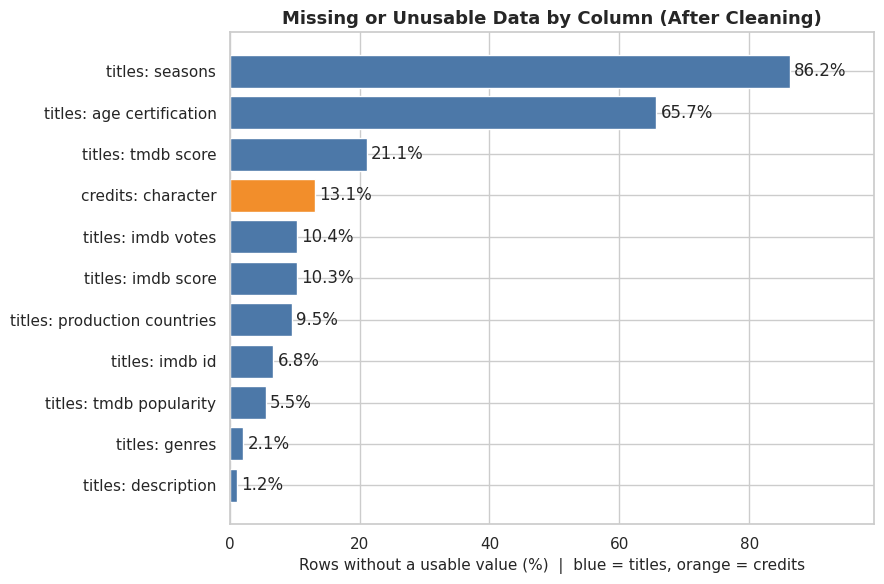

titles: seasons                86.20
titles: age_certification      65.70
titles: tmdb_score             21.10
credits: character             13.10
titles: imdb_votes             10.40
titles: imdb_score             10.30
titles: production_countries    9.50
titles: imdb_id                 6.80
titles: tmdb_popularity         5.50
titles: genres                  2.10
titles: description             1.20

Rating status : {'Not rated': 6484, 'Rated': 3384}
Country status: {'Listed': 8927, 'No country listed': 821, 'Unknown code (XX)': 120}
Genre status  : {'Listed': 9659, 'No genre listed': 209}
IMDb status   : {'Has IMDb score': 8847, 'No IMDb score': 1021}
Character status: {'Listed': 107902, 'Not applicable (director)': 8386, 'Character not listed': 7891}
Titles with no credit rows: 1,007 (10.2%)
Reliable scores (>= 100 votes): 6,864 of 9,868 titles (69.6%)


In [12]:
# Share of each ORIGINAL column with no usable value (empty genre / country lists count as unusable).
gap = titles[TITLE_COLS].isna().mean() * 100
gap["genres"] = (titles["n_genres"] == 0).mean() * 100
gap["production_countries"] = (titles["country_status"] != "Listed").mean() * 100
cgap = credits[CREDIT_COLS].isna().mean() * 100
usable_gap = pd.concat([gap.rename(lambda c: f"titles: {c}"), cgap.rename(lambda c: f"credits: {c}")])
usable_gap = usable_gap[usable_gap > 0].sort_values()
labels = usable_gap.index.str.replace("_", " ")

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE_TYPE["SHOW"] if l.startswith("credits") else BASE_COLOR for l in usable_gap.index]
ax.barh(labels, usable_gap.values, color=colors)
ax.bar_label(ax.containers[0], labels=[f"{v:.1f}%" for v in usable_gap.values], padding=3)
ax.set(title="Missing or Unusable Data by Column (After Cleaning)", xlabel="Rows without a usable value (%)  |  blue = titles, orange = credits", ylabel="")
ax.set_xlim(0, usable_gap.max() * 1.15)
fig.tight_layout()
save_fig(fig, "01_missing_values")

print(usable_gap.sort_values(ascending=False).round(1).to_string())
print("\nRating status :", titles["rating_status"].value_counts().to_dict())
print("Country status:", titles["country_status"].value_counts().to_dict())
print("Genre status  :", titles["genre_status"].value_counts().to_dict())
print("IMDb status   :", titles["imdb_status"].value_counts().to_dict())
print("Character status:", credits["character_status"].value_counts().to_dict())
print(f"Titles with no credit rows: {(titles['has_credits'] == 0).sum():,} ({(titles['has_credits'] == 0).mean():.1%})")
print(f"Reliable scores (>= {MIN_VOTES} votes): {len(rel):,} of {len(titles):,} titles ({len(rel) / len(titles):.1%})")


**Why this chart:** Before trusting any average, we need to know how much of each field is actually usable. A bar chart of the gap per column shows where conclusions rest on partial data.

**Insight:** Most large gaps are structural, not random. Seasons is empty for 86.2% of rows because it only applies to shows. Age certification is missing for 65.7% of titles (6,484, recorded as 'Not rated'), the TMDB score for 21.1%, IMDb votes for 10.4% and the IMDb score for 10.3% (1,021 titles). Production country is unusable for 9.5% (821 empty lists and 120 with the placeholder code XX) and genre for 2.1% (209 titles). In credits, 13.1% of rows have no character: 8,386 are director rows where a character does not apply and 7,891 are actors with no character listed. Separately, 1,007 titles (10.2%) have no credit rows at all, and only 6,864 titles (69.6%) have an IMDb score backed by at least 100 votes.

**Business impact:** Negative. Any age-rating analysis covers just 34.3% of titles, and quality comparisons rest on 69.6% at best. Action: make age certification, country, genre and credits mandatory when a title is ingested, and quote data coverage next to every KPI.

## 10. Univariate analysis — one variable at a time

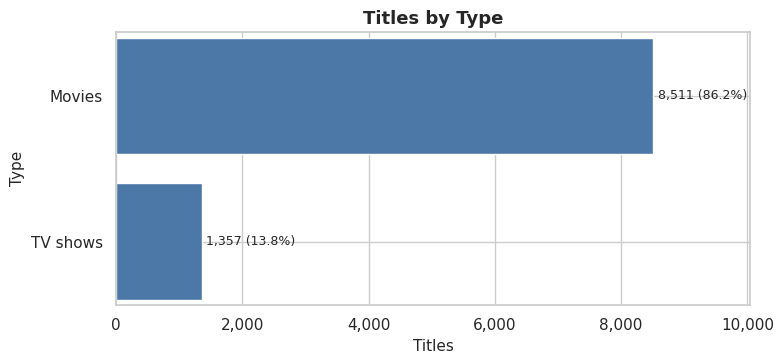

{'Movies': 8511, 'TV shows': 1357} | shares: {'Movies': 86.2, 'TV shows': 13.8}
Movies per show: 6.3
       median_runtime  pct_rated
type                            
MOVIE           91.00      31.70
SHOW            33.00      50.30
Median release year by type: {'MOVIE': 2013, 'SHOW': 2016}


In [13]:
type_counts = titles["type"].map({"MOVIE": "Movies", "SHOW": "TV shows"}).value_counts()
plot_bar(type_counts, "Titles by Type", "Titles", "Type", "02_titles_by_type", horizontal=True, figsize=(8, 3.8))

print(type_counts.to_dict(), "| shares:", (type_counts / len(titles) * 100).round(1).to_dict())
print("Movies per show:", round(type_counts["Movies"] / type_counts["TV shows"], 1))
print(titles.groupby("type").agg(median_runtime=("runtime", "median"),
                                 pct_rated=("age_certification", lambda s: s.notna().mean() * 100)).round(1).to_string())
print("Median release year by type:", titles.groupby("type")["release_year"].median().astype(int).to_dict())


**Why this chart:** Format is the most basic split in a catalogue, and later charts show that movies and shows behave very differently, so we first need to know how the library is divided.

**Insight:** The library holds 8,511 movies (86.2%) and 1,357 TV shows (13.8%), or 6.3 movies for every show. A typical movie runs 91 minutes and a typical show episode 33 minutes. Shows are newer (median release year 2016 against 2013 for movies) and half of them (50.3%) carry an age certification, against 31.7% of movies.

**Business impact:** Mixed. A movie-heavy library is easy to browse in one sitting, but series are the format with the higher scores (chart 13) and the ongoing viewing habit. Action: set a target share for series in the catalogue and track it alongside quality.

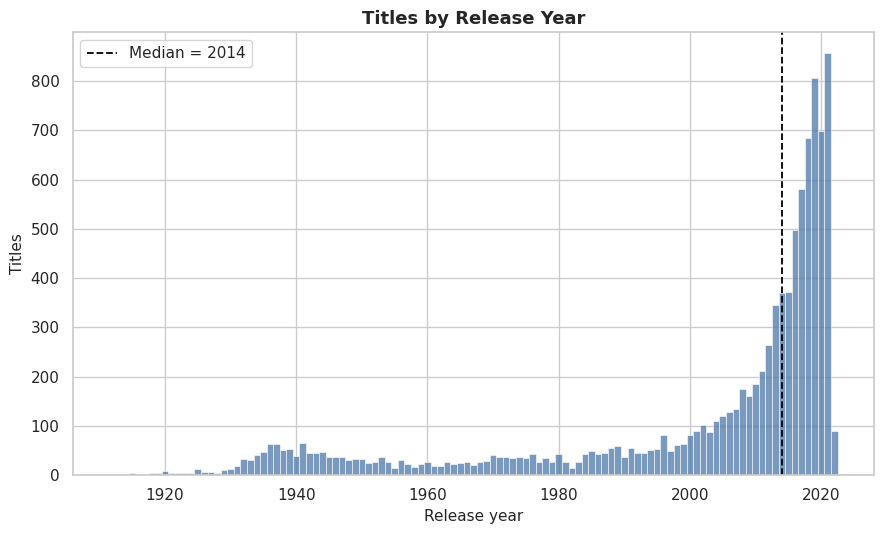

Range: 1912 to 2022 | median year: 2014 | mean: 2001.3
Released 2010 or later: 60.4% | 2015 or later: 46.5% | before 1970: 14.3% | before 1950: 919 titles
Busiest year: 2021 with 856 titles | 2022 (partial year): 89 titles
Titles per decade: {1910: 20, 1920: 65, 1930: 414, 1940: 420, 1950: 254, 1960: 239, 1970: 355, 1980: 408, 1990: 546, 2000: 1189, 2010: 4315, 2020: 1643}


In [14]:
plot_hist(titles["release_year"], "Titles by Release Year", "Release year", "03_release_year",
          bins=np.arange(1911.5, 2023.5, 1), vline_label=f"Median = {titles['release_year'].median():.0f}")

y = titles["release_year"]
print(f"Range: {y.min()} to {y.max()} | median year: {y.median():.0f} | mean: {y.mean():.1f}")
print(f"Released 2010 or later: {(y >= 2010).mean():.1%} | 2015 or later: {(y >= 2015).mean():.1%} | before 1970: {(y < 1970).mean():.1%} | before 1950: {(y < 1950).sum():,} titles")
by_year = y.value_counts().sort_index()
print(f"Busiest year: {by_year.idxmax()} with {by_year.max():,} titles | 2022 (partial year): {by_year[2022]:,} titles")
print("Titles per decade:", titles.groupby("decade").size().to_dict())


**Why this chart:** The age of the catalogue shapes how fresh it feels and how much of it is classic material. A histogram by release year shows both.

**Insight:** Titles run from 1912 to 2022 with a median of 2014. About 60.4% were released in 2010 or later and 46.5% in 2015 or later, while 14.3% pre-date 1970 (919 titles are from before 1950). The busiest year is 2021 with 856 titles; 2022 shows only 89 because it is a partial year. The 2010s hold 4,315 titles against 414 for the 1930s and 420 for the 1940s.

**Business impact:** Mixed. Positive: the library leans recent. Negative: a long tail of classic titles has to be curated separately or it will dilute recommendations. Action: keep 2022 out of trend comparisons, and give classics their own shelf and their own quality rules.

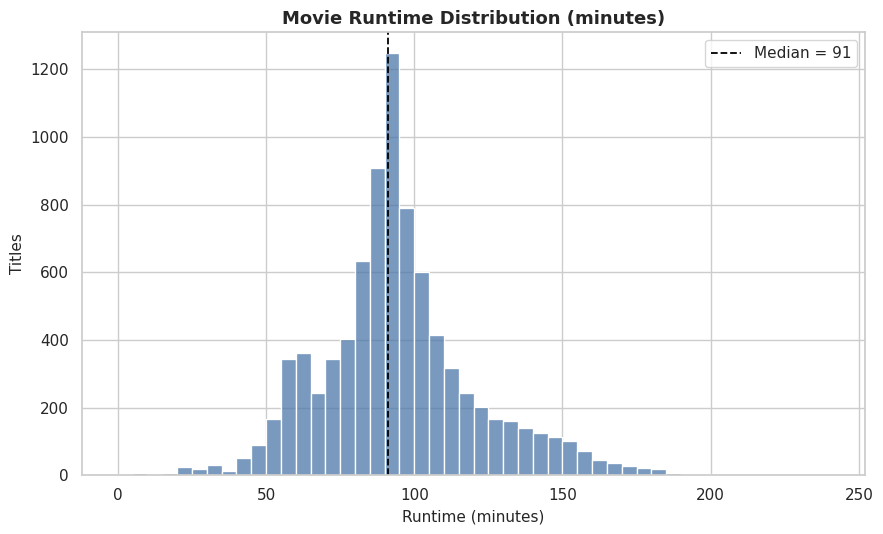

Movies outside the plotted 0-240 minute window: 10 (kept in all statistics)
Median: 91 min | mean: 94.0 | 25th-75th pct: 80-105 | max: 549 min
Movies under 40 min: 108 (1.3%) | 80-120 min: 61.5% | over 150 min: 308 (3.6%)
TV shows (minutes per episode): median 33 | 25th-75th pct 23-47 | over 60 min: 4.9%


In [15]:
plot_hist(movies.loc[movies["runtime"] <= 240, "runtime"], "Movie Runtime Distribution (minutes)", "Runtime (minutes)", "04_movie_runtime",
          bins=np.arange(0, 245, 5))

r = movies["runtime"]
print(f"Movies outside the plotted 0-240 minute window: {(r > 240).sum()} (kept in all statistics)")
print(f"Median: {r.median():.0f} min | mean: {r.mean():.1f} | 25th-75th pct: {r.quantile(.25):.0f}-{r.quantile(.75):.0f} | max: {r.max()} min")
print(f"Movies under 40 min: {(r < 40).sum()} ({(r < 40).mean():.1%}) | 80-120 min: {r.between(80, 120).mean():.1%} | over 150 min: {(r > 150).sum()} ({(r > 150).mean():.1%})")
sr = shows["runtime"]
print(f"TV shows (minutes per episode): median {sr.median():.0f} | 25th-75th pct {sr.quantile(.25):.0f}-{sr.quantile(.75):.0f} | over 60 min: {(sr > 60).mean():.1%}")


**Why this chart:** Runtime decides how a title fits into a viewing session. A histogram for movies shows the usual length and the unusual extremes.

**Insight:** The median movie runs 91 minutes and the middle half run 80–105 minutes; 61.5% fall between 80 and 120 minutes. There is a thin tail of long films: 308 (3.6%) run over 150 minutes and 10 exceed 240, with a maximum of 549 minutes. At the other end, 108 movies (1.3%) run under 40 minutes. TV shows have a median of 33 minutes per episode, and 4.9% run over 60.

**Business impact:** Neutral to negative. Standard lengths suit the usual viewing slots, but the extreme values look like shorts, compilations or miscoded records. Action: tag shorts and compilations as their own category and validate runtimes above 240 minutes before they enter recommendations.

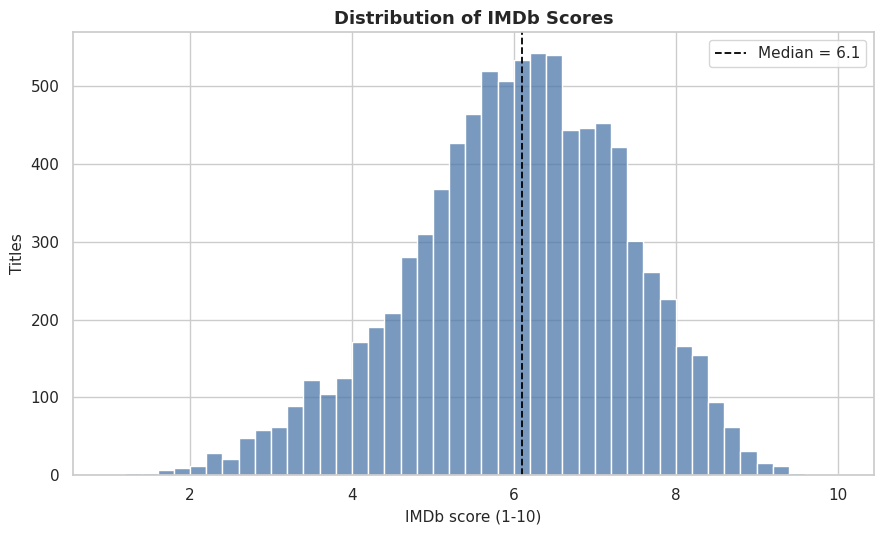

Titles with a score: 8,847 (89.7%)
Median: 6.1 | mean: 5.98 | std: 1.34 | range: 1.1 to 9.9
Strong (7+): 24.9% (2,202) | average (5-6.9): 54.2% | poor (<5): 21.0% (1,854)
Scores of 8 or more: 540 (6.1%) | 9 or more: 33 | below 3: 190
Quality tier counts: {'Poor (<5)': 1854, 'Average (5-6.9)': 4791, 'Strong (7+)': 2202}


In [16]:
plot_hist(scored["imdb_score"], "Distribution of IMDb Scores", "IMDb score (1-10)", "05_imdb_score", bins=np.arange(1, 10.05, 0.2))

s = scored["imdb_score"]
print(f"Titles with a score: {len(s):,} ({len(s) / len(titles):.1%})")
print(f"Median: {s.median():.1f} | mean: {s.mean():.2f} | std: {s.std():.2f} | range: {s.min()} to {s.max()}")
print(f"Strong (7+): {(s >= 7).mean():.1%} ({(s >= 7).sum():,}) | average (5-6.9): {s.between(5, 6.99).mean():.1%} | poor (<5): {(s < 5).mean():.1%} ({(s < 5).sum():,})")
print(f"Scores of 8 or more: {(s >= 8).sum():,} ({(s >= 8).mean():.1%}) | 9 or more: {(s >= 9).sum()} | below 3: {(s < 3).sum()}")
print("Quality tier counts:", scored["quality_tier"].value_counts().reindex(TIER_ORDER).to_dict())


**Why this chart:** The IMDb score is the main quality measure, so its full distribution matters. A histogram shows whether quality is uniform or split into good and bad groups.

**Insight:** 8,847 titles (89.7%) have a score. The median is 6.1 and the mean 5.98, with a standard deviation of 1.34, and the shape is a wide bell with a longer tail on the low side. Only 24.9% of titles (2,202) are strong (7 or higher), 54.2% are average (5–6.9) and 21.0% (1,854) are poor (below 5). 540 titles score 8 or more, 33 score 9 or more, and 190 score below 3.

**Business impact:** Mixed. About one title in four is strong, but one in five is poor. Action: adopt the three quality tiers (Strong, Average, Poor) as standard reporting and track the share of each tier for every batch of new titles.

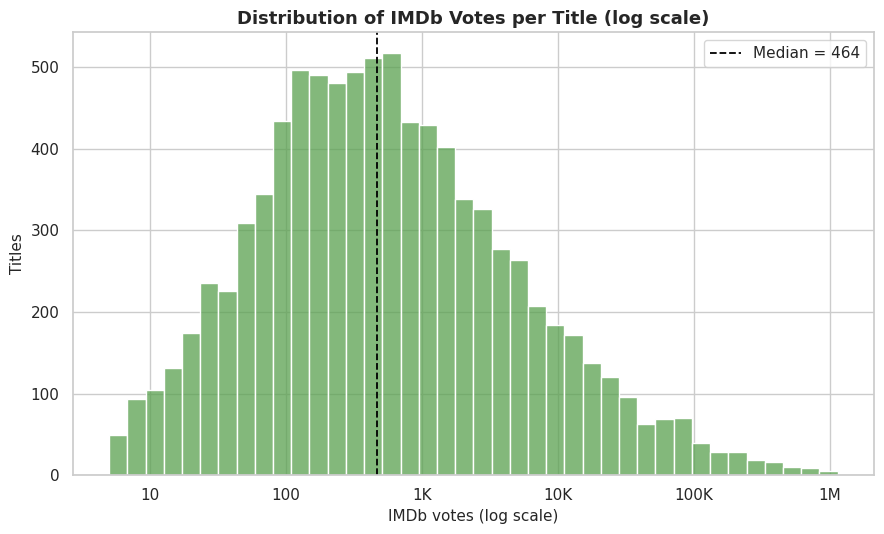

Titles with a vote count: 8,837
Median: 464 | mean: 8,536 | 90th pct: 11,067 | max: 1,133,692 (Titanic)
Top 10% of titles hold 87.2% of all votes; top 1% hold 44.8%; total votes 75,436,919
Under 100 votes: 1,973 (22.3%) | under 1,000: 63.5% | 10,000 or more: 934 | 100,000 or more: 153


In [17]:
plot_hist(scored["imdb_votes"], "Distribution of IMDb Votes per Title (log scale)", "IMDb votes (log scale)", "06_imdb_votes_log", bins=40, log_x=True, color="#59A14F")

v = scored["imdb_votes"].dropna()
top10 = v.nlargest(int(len(v) * 0.10)).sum() / v.sum()
top1 = v.nlargest(int(len(v) * 0.01)).sum() / v.sum()
print(f"Titles with a vote count: {len(v):,}")
print(f"Median: {v.median():,.0f} | mean: {v.mean():,.0f} | 90th pct: {v.quantile(.9):,.0f} | max: {v.max():,.0f} ({scored.loc[v.idxmax(), 'title']})")
print(f"Top 10% of titles hold {top10:.1%} of all votes; top 1% hold {top1:.1%}; total votes {v.sum():,.0f}")
print(f"Under 100 votes: {(v < 100).sum():,} ({(v < 100).mean():.1%}) | under 1,000: {(v < 1000).mean():.1%} | 10,000 or more: {(v >= 10_000).sum():,} | 100,000 or more: {(v >= 100_000).sum()}")


**Why this chart:** Votes measure how many people have engaged with a title. A log axis is needed because a handful of titles have hundreds of thousands of votes while most have very few.

**Insight:** Attention is extremely concentrated. The median title has 464 votes but the mean is 8,536, and the maximum is 1,133,692 (Titanic). The top 10% of titles hold 87.2% of all 75.4 million votes and the top 1% hold 44.8%. 22.3% of titles (1,973) have fewer than 100 votes and 63.5% fewer than 1,000, while only 934 reach 10,000 and 153 reach 100,000.

**Business impact:** Negative. Most of the library is nearly invisible in the audience signal, and scores for the 22.3% with under 100 votes are too noisy to trust. Action: use a minimum-votes rule (100 in this project) for quality rankings, and build a separate discovery path for good titles with thin audiences.

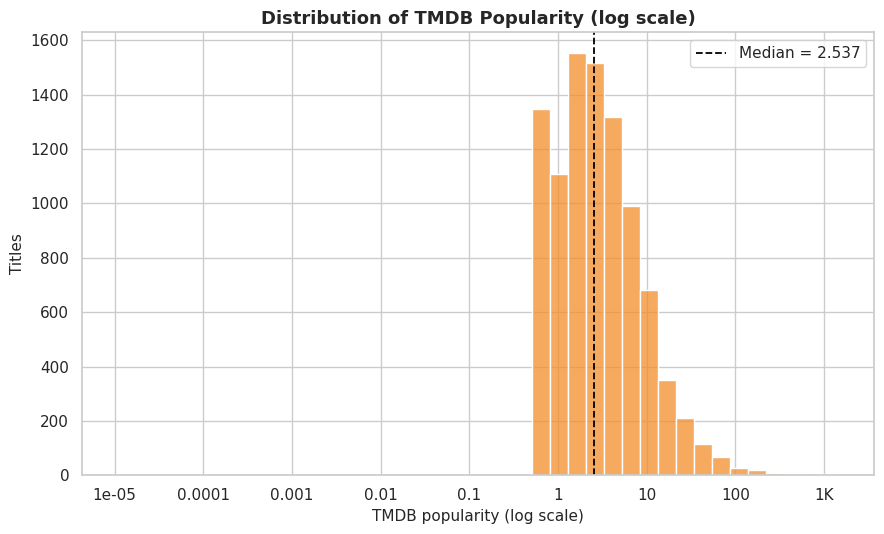

Titles with popularity: 9,321 | median: 2.54 | mean: 6.91 | 90th pct: 12.11 | max: 1,438 (All the Old Knives)
Top 10% of titles hold 59.3% of total popularity; top 1% hold 27.7%
Popularity above 10: 1,199 (12.9%) | above 100: 55 | below 1: 19.8%
Ten most popular titles: ['All the Old Knives (2022)', 'Harina (2022)', 'The eighth clause (2022)', 'Hotel Transylvania: Transformania (2022)', 'Sonic the Hedgehog (2020)', 'Clifford the Big Red Dog (2021)', 'Queen of Spades (2021)', 'Meander (2021)', 'Suits (2011)', 'Better Call Saul (2015)']


In [18]:
plot_hist(titles["tmdb_popularity"], "Distribution of TMDB Popularity (log scale)", "TMDB popularity (log scale)", "07_tmdb_popularity_log", bins=40, log_x=True, color="#F28E2B")

p = titles["tmdb_popularity"].dropna()
print(f"Titles with popularity: {len(p):,} | median: {p.median():.2f} | mean: {p.mean():.2f} | 90th pct: {p.quantile(.9):.2f} | max: {p.max():,.0f} ({titles.loc[p.idxmax(), 'title']})")
print(f"Top 10% of titles hold {p.nlargest(int(len(p) * 0.10)).sum() / p.sum():.1%} of total popularity; top 1% hold {p.nlargest(int(len(p) * 0.01)).sum() / p.sum():.1%}")
print(f"Popularity above 10: {(p > 10).sum():,} ({(p > 10).mean():.1%}) | above 100: {(p > 100).sum()} | below 1: {(p < 1).mean():.1%}")
print("Ten most popular titles:", titles.nlargest(10, "tmdb_popularity")[["title", "type", "release_year"]].apply(lambda r: f"{r['title']} ({r['release_year']})", axis=1).tolist())


**Why this chart:** TMDB popularity is a current-attention index that complements IMDb votes. Its distribution shows how unevenly attention is spread today.

**Insight:** The median popularity is 2.54 and the mean 6.91, with the 90th percentile at 12.11 and a maximum of 1,438 (All the Old Knives). The top 10% of titles hold 59.3% of total popularity and the top 1% hold 27.7%, which is less concentrated than votes (87.2%). 1,199 titles (12.9%) score above 10, 55 above 100, and 19.8% fall below 1. Eight of the ten most popular titles were released in 2020–2022, and the other two are well-known series (Suits and Better Call Saul).

**Business impact:** Mixed. Popularity is a snapshot that favours new releases, while votes reflect lasting reputation. Action: use popularity for a 'trending now' shelf and votes together with scores for evergreen quality lists.

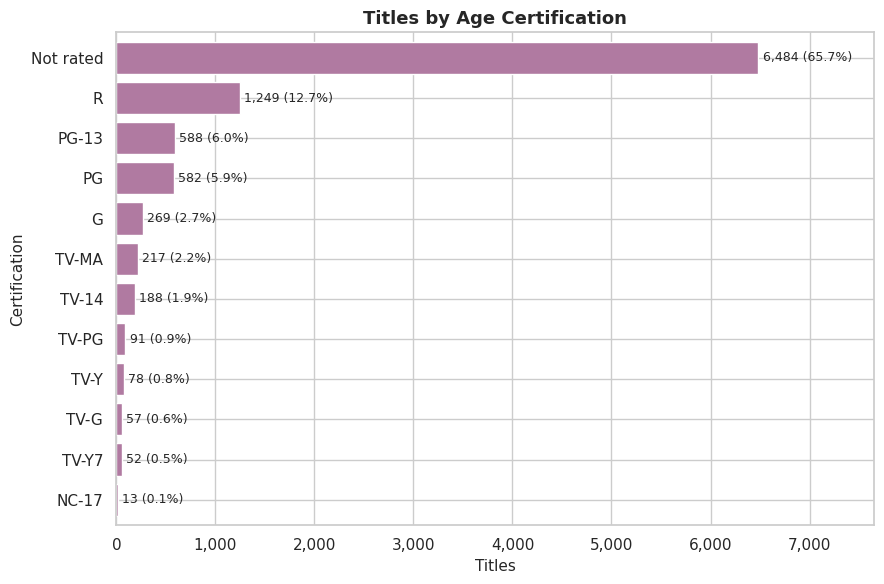

{'Not rated': 6484, 'R': 1249, 'PG-13': 588, 'PG': 582, 'G': 269, 'TV-MA': 217, 'TV-14': 188, 'TV-PG': 91, 'TV-Y': 78, 'TV-G': 57, 'TV-Y7': 52, 'NC-17': 13}
Not rated: 6,484 (65.7%) | rated: 3,384
Among rated titles: R 36.9% | PG-13 17.4% | PG 17.2% | TV-MA 6.4%
Audience band, rated titles only: {'Adult': 43.7, 'Kids & Family': 33.4, 'Teen': 22.9}
Not-rated share by type: {'MOVIE': 68.3, 'SHOW': 49.7}
Not-rated share by era: {'Up to 1969': 89.9, '1970-89': 33.7, '1990-99': 45.4, '2000-09': 43.9, '2010-17': 63.3, '2018-22': 76.6}


In [19]:
cert_counts = titles["age_certification"].fillna("Not rated").value_counts()
plot_bar(cert_counts, "Titles by Age Certification", "Titles", "Certification", "08_age_certification", color="#B07AA1", total=len(titles), figsize=(9, 6))

rated = titles["age_certification"].dropna()
print(cert_counts.to_dict())
print(f"Not rated: {cert_counts['Not rated']:,} ({cert_counts['Not rated'] / len(titles):.1%}) | rated: {len(rated):,}")
print(f"Among rated titles: R {(rated == 'R').mean():.1%} | PG-13 {(rated == 'PG-13').mean():.1%} | PG {(rated == 'PG').mean():.1%} | TV-MA {(rated == 'TV-MA').mean():.1%}")
print("Audience band, rated titles only:", (titles.loc[titles["audience_band"] != "Not rated", "audience_band"].value_counts(normalize=True) * 100).round(1).to_dict())
print("Not-rated share by type:", (titles.groupby("type")["age_certification"].apply(lambda s: s.isna().mean() * 100)).round(1).to_dict())
print("Not-rated share by era:", (titles.groupby("era", observed=True)["age_certification"].apply(lambda s: s.isna().mean() * 100)).round(1).to_dict())


**Why this chart:** Age certification drives parental controls and audience filters, so its coverage and mix are operationally important.

**Insight:** 6,484 titles (65.7%) have no certification, including 68.3% of movies and 49.7% of shows. Among the 3,384 rated titles, R is the largest group (1,249, or 36.9% of rated titles), then PG-13 (17.4%), PG (17.2%) and TV-MA (6.4%). By audience band, 43.7% of rated titles are adult, 33.4% kids and family and 22.9% teen. The unrated share is 89.9% for titles up to 1969, falls to 33.7% for 1970–89, and then climbs again to 76.6% for 2018–22.

**Business impact:** Negative. Parental controls and audience filters cannot work for two thirds of the library, and the gap is widest for the newest titles. Action: fill certifications for 2018–22 titles first, and require a certification for every new title.

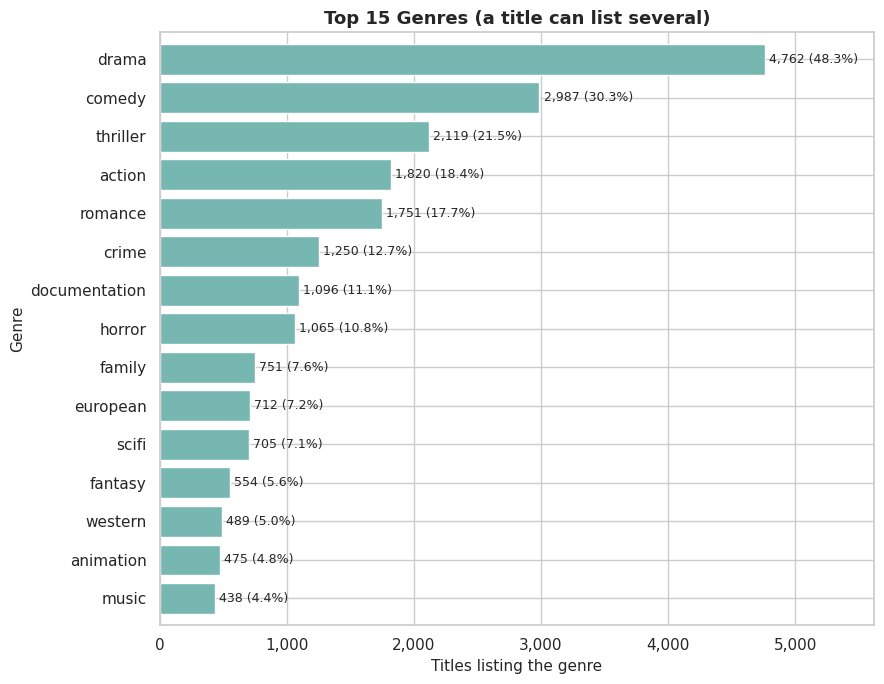

Distinct genres: 19 | average genres per title (with a genre): 2.28 | titles with no genre: 209
Top 5: {'drama': 4762, 'comedy': 2987, 'thriller': 2119, 'action': 1820, 'romance': 1751}
Drama share of titles: 48.3% | comedy: 30.3% | drama or comedy: 66.9%
Smallest genres: {'music': 438, 'history': 396, 'war': 324, 'sport': 228, 'reality': 138}
Genres per title: {0: 209, 1: 3057, 2: 2914, 3: 2207, 4: 1006, 5: 357, 6: 88, 7: 23, 8: 7}


In [20]:
genre_counts = genre_long["genre"].value_counts()
plot_bar(genre_counts.head(15), "Top 15 Genres (a title can list several)", "Titles listing the genre", "Genre", "09_top15_genres",
         color="#76B7B2", total=len(titles), figsize=(9, 7))

print(f"Distinct genres: {len(genre_counts)} | average genres per title (with a genre): {titles.loc[titles['n_genres'] > 0, 'n_genres'].mean():.2f} | titles with no genre: {(titles['n_genres'] == 0).sum()}")
print("Top 5:", genre_counts.head(5).to_dict())
print(f"Drama share of titles: {genre_counts['drama'] / len(titles):.1%} | comedy: {genre_counts['comedy'] / len(titles):.1%} | drama or comedy: {genre_long.loc[genre_long['genre'].isin(['drama', 'comedy']), 'id'].nunique() / len(titles):.1%}")
print("Smallest genres:", genre_counts.tail(5).to_dict())
print("Genres per title:", titles["n_genres"].value_counts().sort_index().to_dict())


**Why this chart:** Genre shows what kind of content the catalogue really contains and where variety is thin.

**Insight:** The dataset has 19 genres. Drama (4,762 titles, 48.3%) and comedy (2,987, 30.3%) lead, followed by thriller (2,119), action (1,820) and romance (1,751); 66.9% of titles list drama or comedy. A title lists 2.28 genres on average, and 209 list none. The smallest genres are reality (138 titles), sport (228) and war (324).

**Business impact:** Mixed. A drama and comedy core gives broad appeal, but niche genres such as reality, sport and animation (475) are thin. Action: compare genre share with viewing demand once viewing data is available, and treat the 209 titles with no genre as a data-quality fix.

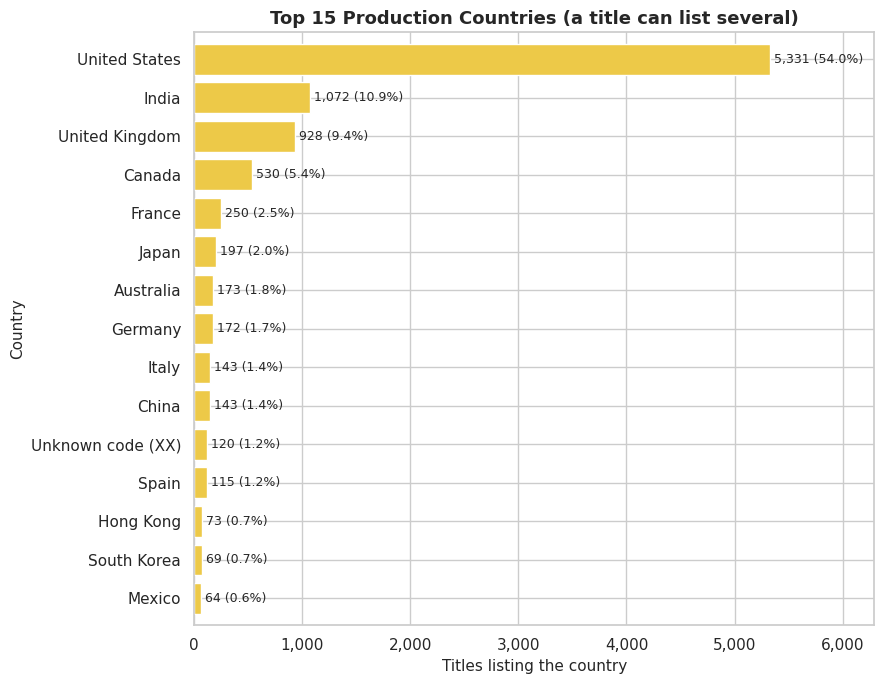

Distinct country codes (excluding XX): 116 | titles with no country: 821 | code XX: 120
Top 6: {'United States': 5331, 'India': 1072, 'United Kingdom': 928, 'Canada': 530, 'France': 250, 'Japan': 197}
US share of titles: 54.0% | US + India: 64.9%
Titles listing more than one country: 874 (8.9%)
Countries with fewer than 10 titles: 76 of 116
Share of titles with no known country by era: {'Up to 1969': 1.1, '1970-89': 3.1, '1990-99': 2.9, '2000-09': 4.0, '2010-17': 5.7, '2018-22': 21.7}


In [21]:
country_counts = country_long["country"].value_counts()
plot_bar(country_counts.head(15), "Top 15 Production Countries (a title can list several)", "Titles listing the country", "Country", "10_top15_countries",
         color="#EDC948", total=len(titles), figsize=(9, 7))

known = country_long[country_long["country_code"] != "XX"]
print(f"Distinct country codes (excluding XX): {known['country_code'].nunique()} | titles with no country: {(titles['country_status'] == 'No country listed').sum()} | code XX: {(titles['country_status'] == 'Unknown code (XX)').sum()}")
print("Top 6:", country_counts.head(6).to_dict())
print(f"US share of titles: {country_counts['United States'] / len(titles):.1%} | US + India: {(country_counts['United States'] + country_counts['India']) / len(titles):.1%}")
print(f"Titles listing more than one country: {(titles['n_countries'] > 1).sum():,} ({(titles['n_countries'] > 1).mean():.1%})")
print(f"Countries with fewer than 10 titles: {(known['country_code'].value_counts() < 10).sum()} of {known['country_code'].nunique()}")
print("Share of titles with no known country by era:", (titles.groupby("era", observed=True)["country_status"].apply(lambda s: (s != "Listed").mean() * 100)).round(1).to_dict())


**Why this chart:** Country of production shows how global the catalogue is and where sourcing is concentrated.

**Insight:** 116 country codes appear, but the catalogue is concentrated: the United States is listed on 5,331 titles (54.0%), India on 1,072 (10.9%), the United Kingdom on 928 (9.4%) and Canada on 530 (5.4%). Titles can list several countries, and 874 (8.9%) do. 76 of the 116 countries have fewer than 10 titles. 821 titles list no country and 120 use the code XX, and the share without a known country is 21.7% for 2018–22 titles against 1.1% for titles up to 1969.

**Business impact:** Negative for diversity and for localisation. Most of the world is represented by a handful of titles, and the newest content is the least well labelled. Action: fix country capture for recent titles, and set sourcing targets for regions that score well (chart 15).

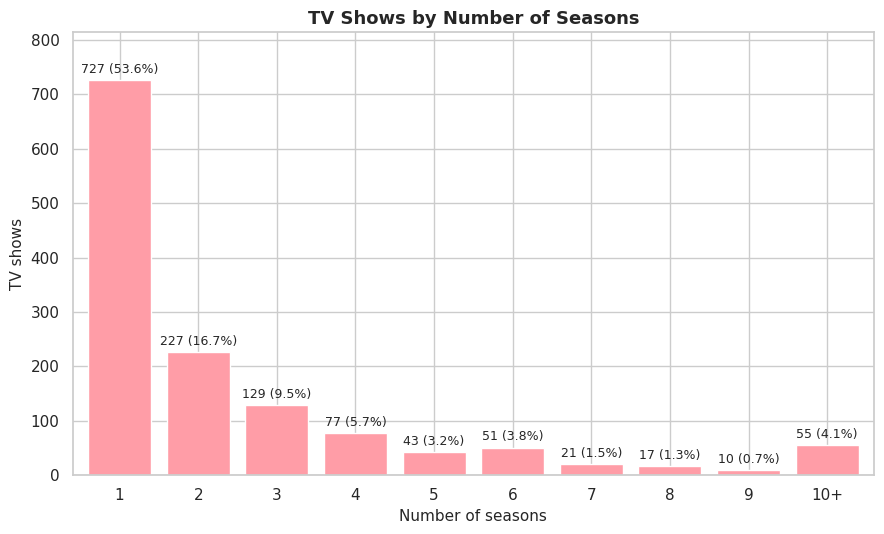

Median seasons: 1 | mean: 2.79 | max: 51 (Great Performances)
One season: 727 (53.6%) | 1-2 seasons: 70.3% | 5 or more: 197 (14.5%) | 10 or more: 55
Median IMDb score by seasons band:  {'1': {'count': 568, 'median': 7.2}, '2': {'count': 208, 'median': 7.3}, '3-4': {'count': 197, 'median': 7.5}, '5+': {'count': 193, 'median': 7.4}}


In [22]:
season_counts = shows["seasons"].clip(upper=10).astype(int).value_counts().sort_index()
season_counts.index = [f"{i}+" if i == 10 else str(i) for i in season_counts.index]
plot_bar(season_counts, "TV Shows by Number of Seasons", "Number of seasons", "TV shows", "11_seasons", horizontal=False, color="#FF9DA7", total=len(shows), figsize=(9, 5.5))

sn = shows["seasons"]
print(f"Median seasons: {sn.median():.0f} | mean: {sn.mean():.2f} | max: {sn.max():.0f} ({shows.loc[sn.idxmax(), 'title']})")
print(f"One season: {(sn == 1).sum()} ({(sn == 1).mean():.1%}) | 1-2 seasons: {(sn <= 2).mean():.1%} | 5 or more: {(sn >= 5).sum()} ({(sn >= 5).mean():.1%}) | 10 or more: {(sn >= 10).sum()}")
print(f"Median IMDb score by seasons band: ", shows.assign(b=pd.cut(sn, [0, 1, 2, 4, 100], labels=["1", "2", "3-4", "5+"])).groupby("b", observed=True)["imdb_score"].agg(["count", "median"]).round(2).to_dict("index"))


**Why this chart:** The number of seasons shows how long shows keep running, which is a proxy for lasting audience appeal.

**Insight:** 727 of 1,357 shows (53.6%) have just one season and 70.3% have one or two. The median is one season and the mean 2.79. 197 shows (14.5%) run five or more seasons, 55 run ten or more, and the longest is Great Performances with 51. Median IMDb scores rise slightly with length: 7.2 for one season, 7.3 for two, 7.5 for three to four and 7.4 for five or more.

**Business impact:** Mixed. Many one-season shows mean a lot of unfinished stories, while the long-running shows are not lower in quality. Action: prioritise renewing or acquiring multi-season series with proven scores, and label one-season shows clearly so viewers know what to expect.

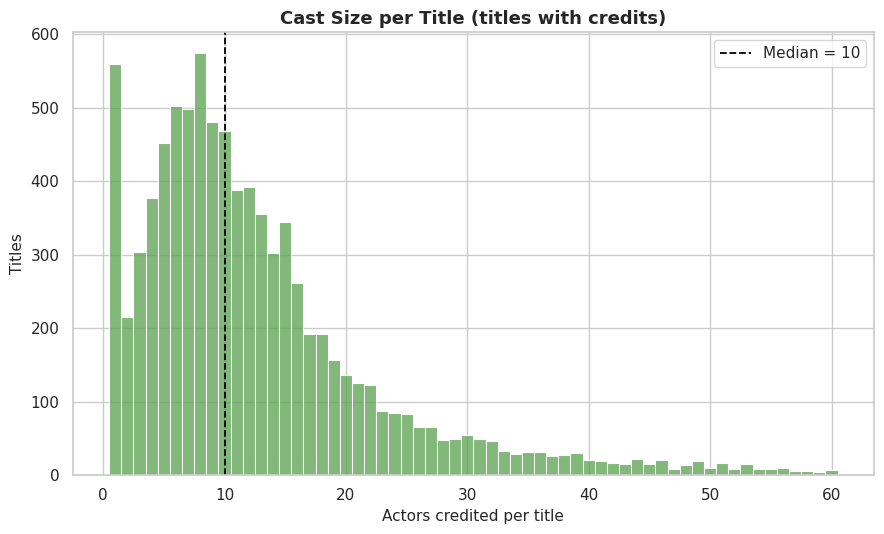

Titles with at least one actor credit: 8,605 (87.2%) | with no credit rows: 1,007
Median cast: 10 | mean: 13.5 | 90th pct: 27 | max: 136 | above 60 (outside the plotted window): 89
Cast of 5 or fewer: 22.2% | 10 or fewer: 51.5%
Credit rows by role: {'ACTOR': 115793, 'DIRECTOR': 8386}
Titles with a credited director: 7,747 (87.4% of titles with credits) | more than one director: 485
Distinct people: 80,508 | appear in only one title: 76.7% | in 10 or more titles: 526
Median cast size by type: {'MOVIE': 11.0, 'SHOW': 7.0}


In [23]:
with_cast = titles.loc[titles["cast_size"] > 0, "cast_size"]
plot_hist(with_cast, "Cast Size per Title (titles with credits)", "Actors credited per title", "12_cast_size", bins=np.arange(0.5, 61.5, 1), color="#59A14F")

print(f"Titles with at least one actor credit: {len(with_cast):,} ({len(with_cast) / len(titles):.1%}) | with no credit rows: {(titles['has_credits'] == 0).sum():,}")
print(f"Median cast: {with_cast.median():.0f} | mean: {with_cast.mean():.1f} | 90th pct: {with_cast.quantile(.9):.0f} | max: {with_cast.max()} | above 60 (outside the plotted window): {(with_cast > 60).sum()}")
print(f"Cast of 5 or fewer: {(with_cast <= 5).mean():.1%} | 10 or fewer: {(with_cast <= 10).mean():.1%}")
print("Credit rows by role:", credits["role"].value_counts().to_dict())
dirs = titles.loc[titles["has_credits"] == 1, "n_directors"]
print(f"Titles with a credited director: {(dirs > 0).sum():,} ({(dirs > 0).mean():.1%} of titles with credits) | more than one director: {(dirs > 1).sum()}")
per_person = credits.groupby("person_id")["id"].nunique()
print(f"Distinct people: {len(per_person):,} | appear in only one title: {(per_person == 1).mean():.1%} | in 10 or more titles: {(per_person >= 10).sum():,}")
print("Median cast size by type:", titles[titles["cast_size"] > 0].groupby("type")["cast_size"].median().to_dict())


**Why this chart:** Cast size shows how deep the credits are and gives a first look at the people side of the data, which the next charts build on.

**Insight:** 8,605 titles (87.2%) have at least one credited actor, and 1,007 have no credits at all. The median cast is 10 (mean 13.5, 90th percentile 27, maximum 136); 22.2% of titles credit five actors or fewer. Movies have a median cast of 11 against 7 for shows. Credits hold 115,793 actor rows and 8,386 director rows, and 7,747 titles have a credited director (485 have more than one). Of 80,508 distinct people, 76.7% appear in only one title and just 526 appear in ten or more.

**Business impact:** Mixed. The talent pool is broad but shallow, so 'more from this actor' recommendations have few anchors for most people. Action: complete credits for the 10.2% of titles with none, and limit talent-based recommendations to the small group of people with several titles.

## 11. Bivariate analysis — numerical vs categorical

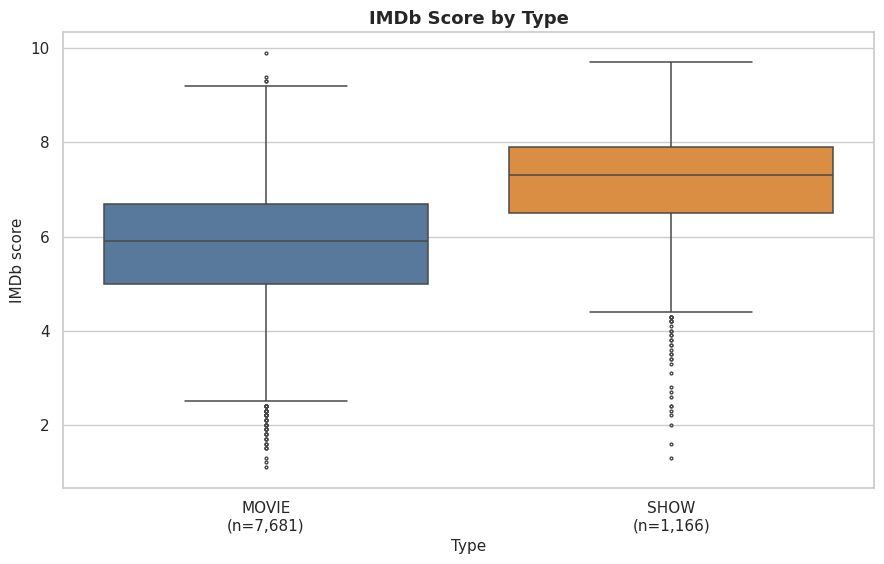

,n,median,mean,p10,p90,share_strong_%,share_poor_%
type,,,,,,,
MOVIE,7681,5.90,5.80,4.10,7.40,18.96,23.36
SHOW,1166,7.30,7.12,5.60,8.40,63.98,5.15


Median gap (shows - movies): 1.4 points
Same comparison on reliable scores only (>= 100 votes): {'MOVIE': {'count': 6020, 'median': 5.9}, 'SHOW': {'count': 844, 'median': 7.3}}


In [24]:
plot_box(scored, "type", "imdb_score", "IMDb Score by Type", "Type", "IMDb score", "13_score_by_type",
         order=TYPE_ORDER, palette=PALETTE_TYPE)

by_type = scored.groupby("type")["imdb_score"].agg(n="count", median="median", mean="mean", p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9))
by_type["share_strong_%"] = scored.groupby("type")["imdb_score"].apply(lambda s: (s >= 7).mean() * 100)
by_type["share_poor_%"] = scored.groupby("type")["imdb_score"].apply(lambda s: (s < 5).mean() * 100)
display(by_type.loc[TYPE_ORDER].round(2))
print(f"Median gap (shows - movies): {by_type.loc['SHOW', 'median'] - by_type.loc['MOVIE', 'median']:.1f} points")
r2 = rel.groupby("type")["imdb_score"].agg(["count", "median"])
print("Same comparison on reliable scores only (>= 100 votes):", r2.round(2).to_dict("index"))


**Why this chart:** A box plot compares the full score distribution of movies and shows side by side, with the number of titles under each box.

**Insight:** Shows score much higher than movies: a median of 7.3 (mean 7.12) against 5.9 (mean 5.80), a gap of 1.4 points. 64.0% of shows score 7 or higher against 19.0% of movies, and only 5.2% of shows are poor against 23.4% of movies. The gap is identical on reliable scores (7.3 for 844 shows against 5.9 for 6,020 movies).

**Business impact:** Positive for series, negative for the movie library. Shows are 13.8% of the catalogue, yet the format supplies far more strong titles than its size suggests. Caveat: shows that get scored may be a more selected group. Action: raise the share of series in acquisition plans, and apply a stricter quality gate to movies.

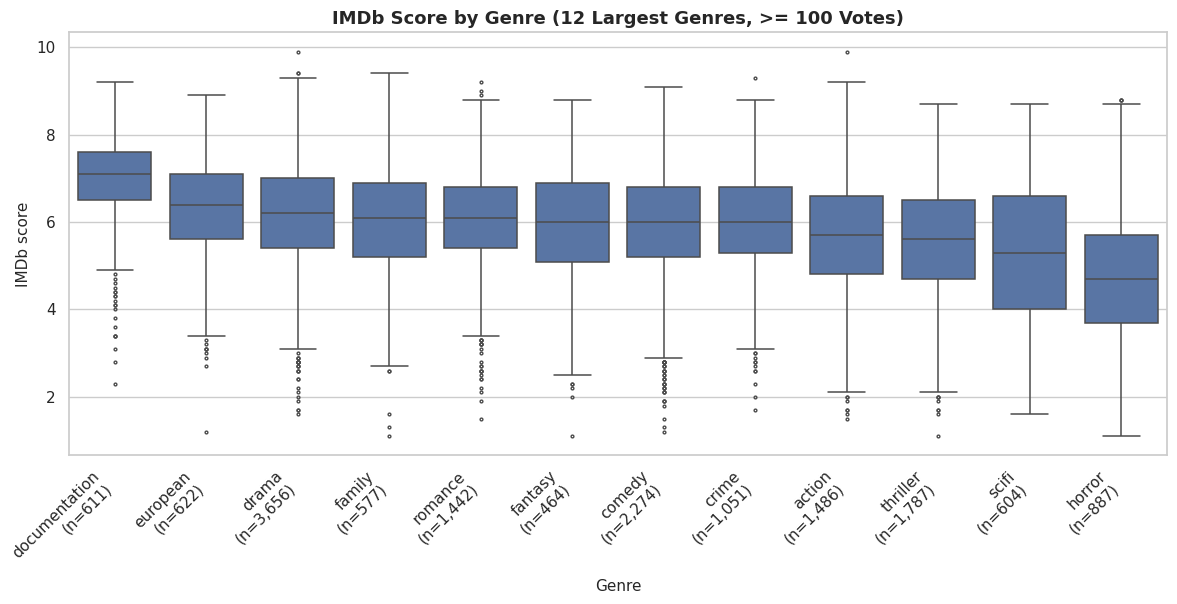

,n,median,mean,share_strong_%,share_poor_%
genre,,,,,
documentation,611,7.10,6.97,57.77,3.60
european,622,6.40,6.33,31.19,12.22
drama,3656,6.20,6.15,25.11,14.61
family,577,6.10,6.04,23.05,16.98
romance,1442,6.10,6.05,20.11,13.87
fantasy,464,6.00,5.93,22.63,22.41
comedy,2274,6.00,5.96,22.08,19.22
crime,1051,6.00,6.03,23.41,17.13
action,1486,5.70,5.70,18.98,27.39


Reliable-score median for all titles: 6.0


In [25]:
top12 = genre_scored["genre"].value_counts().head(12).index
gdata = genre_scored[genre_scored["genre"].isin(top12)]
g_order = list(gdata.groupby("genre")["imdb_score"].median().sort_values(ascending=False).index)
plot_box(gdata, "genre", "imdb_score", "IMDb Score by Genre (12 Largest Genres, >= 100 Votes)", "Genre", "IMDb score", "14_score_by_genre",
         order=g_order, figsize=(12, 6.2), rotate=45)

g_stats = gdata.groupby("genre")["imdb_score"].agg(n="count", median="median", mean="mean")
g_stats["share_strong_%"] = gdata.groupby("genre")["imdb_score"].apply(lambda s: (s >= 7).mean() * 100)
g_stats["share_poor_%"] = gdata.groupby("genre")["imdb_score"].apply(lambda s: (s < 5).mean() * 100)
display(g_stats.loc[g_order].round(2))
print(f"Reliable-score median for all titles: {rel['imdb_score'].median():.1f}")


**Why this chart:** Genre is the main content decision a catalogue team makes. Box plots of score for the twelve largest genres, limited to titles with at least 100 votes, show which genres carry quality and which carry risk.

**Insight:** Documentary is clearly best: median 7.1, 57.8% of titles strong and only 3.6% poor. European (6.4) and drama (6.2, the largest genre with 3,656 scored titles) follow. At the bottom, horror has a median of 4.7 with 57.3% of titles below 5 and only 6.4% strong, followed by sci-fi (5.3, 43.2% poor), thriller (5.6, 32.7% poor) and action (5.7, 27.4% poor). The gap between best and worst genre is 2.4 points, and the all-title median is 6.0.

**Business impact:** Negative for horror, sci-fi, thriller and action, which are all large genres. Action: apply a quality gate in these genres and buy selectively, while expanding documentary, which has both high quality and low risk.

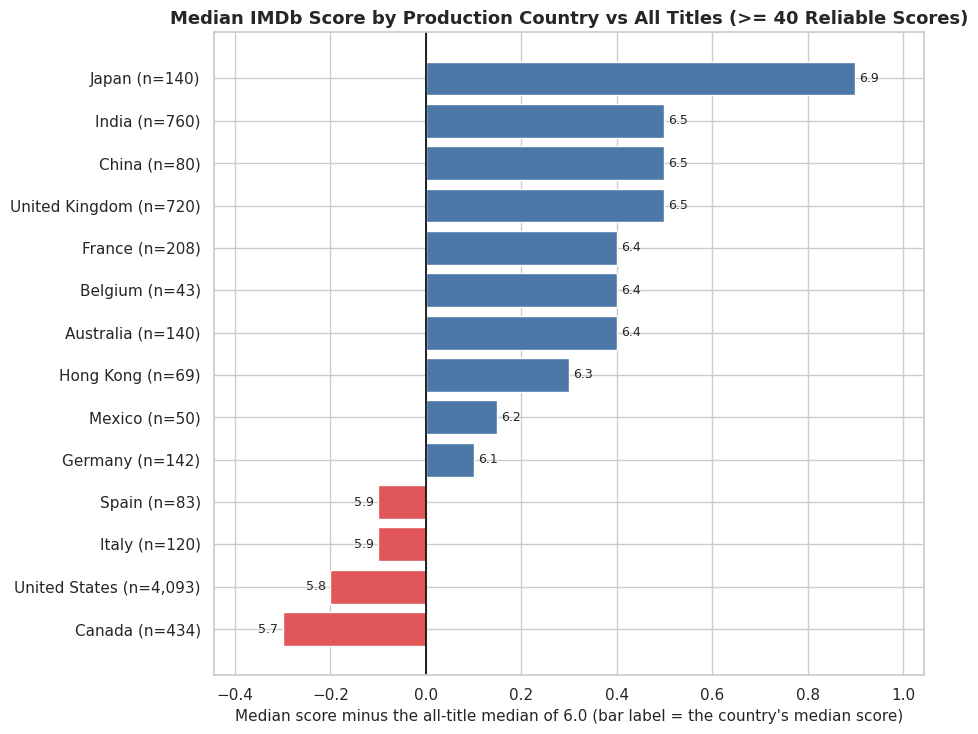

Countries with >= 40 reliable scores: 14
Highest: [{'country': 'Japan', 'n': 140, 'median': 6.9}, {'country': 'India', 'n': 760, 'median': 6.5}, {'country': 'China', 'n': 80, 'median': 6.5}, {'country': 'United Kingdom', 'n': 720, 'median': 6.5}]
Lowest : [{'country': 'Canada', 'n': 434, 'median': 5.7}, {'country': 'United States', 'n': 4093, 'median': 5.8}, {'country': 'Italy', 'n': 120, 'median': 5.9}, {'country': 'Spain', 'n': 83, 'median': 5.9}]
Below the overall median: 4 of 14


In [26]:
c_stats = (country_scored[country_scored["country_code"] != "XX"].groupby(["country_code", "country"])["imdb_score"]
           .agg(n="count", median="median").reset_index().query("n >= 40").sort_values("median"))
overall_med = rel["imdb_score"].median()

dev = c_stats["median"] - overall_med
fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.barh([f"{c} (n={n:,})" for c, n in zip(c_stats["country"], c_stats["n"])], dev, color=["#E15759" if v < 0 else "#4C78A8" for v in dev])
ax.bar_label(ax.containers[0], labels=[f"{m:.1f}" for m in c_stats["median"]], padding=3, fontsize=9)
ax.axvline(0, color="black", lw=1.2)
ax.set(title="Median IMDb Score by Production Country vs All Titles (>= 40 Reliable Scores)",
       xlabel=f"Median score minus the all-title median of {overall_med:.1f} (bar label = the country's median score)", ylabel="")
ax.margins(x=0.12)
fig.tight_layout()
save_fig(fig, "15_median_score_by_country")

print(f"Countries with >= 40 reliable scores: {len(c_stats)}")
print("Highest:", c_stats.sort_values("median", ascending=False).head(4)[["country", "n", "median"]].round(2).to_dict("records"))
print("Lowest :", c_stats.head(4)[["country", "n", "median"]].round(2).to_dict("records"))
print("Below the overall median:", (c_stats["median"] < overall_med).sum(), "of", len(c_stats))


**Why this chart:** Averages by country show whether some sourcing regions consistently deliver better titles. Only countries with at least 40 titles that have 100 or more votes are shown, and bars show the distance from the all-title median.

**Insight:** Of 14 countries that meet the rule, Japan leads with a median of 6.9 (140 titles), followed by India, China and the United Kingdom at 6.5. The lowest are Canada at 5.7 (434 titles) and the United States at 5.8 (4,093 titles), with Italy and Spain at 5.9. Four of the 14 countries sit below the all-title median of 6.0, and because the United States supplies 54.0% of the catalogue it pulls the overall median down.

**Business impact:** Positive for sourcing outside North America. Action: increase acquisition from Japan, India, the United Kingdom and China, keeping in mind that some of them, such as Belgium (43 titles), Mexico (50) and China (80), rest on small samples, and review the quality gate on United States and Canadian additions.

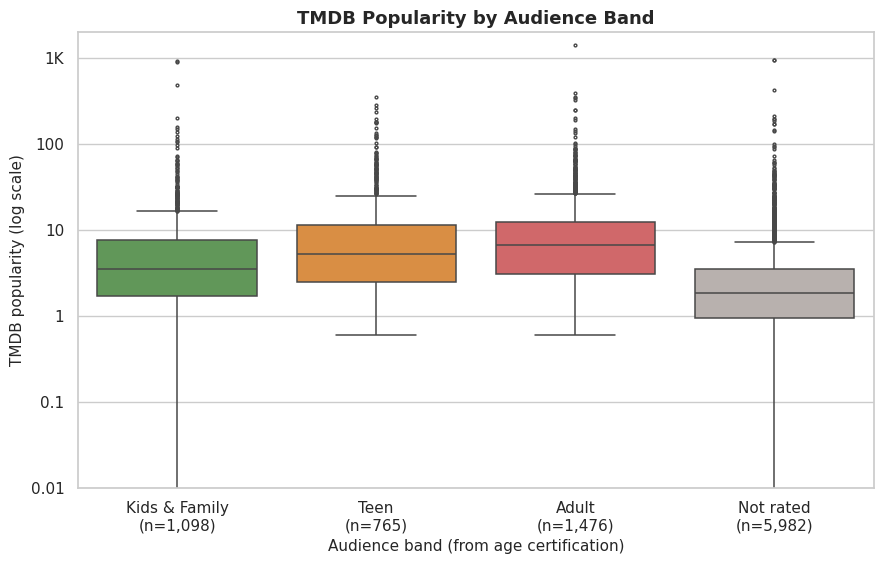

Titles below 0.01 popularity (outside the plotted window, kept in statistics): 6


,n,median,mean,p90
audience_band,,,,
Kids & Family,1098,3.51,9.80,15.90
Teen,765,5.34,14.02,30.56
Adult,1476,6.69,13.48,23.48
Not rated,5982,1.84,3.85,6.55


Median popularity: rated titles 5.14 | not rated 1.84
Median release year by band: {'Kids & Family': 2008.0, 'Teen': 2012.0, 'Adult': 2010.0, 'Not rated': 2015.0}
Median IMDb score by band: {'Kids & Family': 6.2, 'Teen': 6.3, 'Adult': 6.0, 'Not rated': 6.0}


In [27]:
pop = titles.dropna(subset=["tmdb_popularity"])
pop = pop[pop["tmdb_popularity"] > 0]
plot_box(pop, "audience_band", "tmdb_popularity", "TMDB Popularity by Audience Band", "Audience band (from age certification)",
         "TMDB popularity (log scale)", "16_popularity_by_audience_band", order=BAND_ORDER, palette=PALETTE_BAND, log_y=True, ylim=(0.01, 2000))

print(f"Titles below 0.01 popularity (outside the plotted window, kept in statistics): {(pop['tmdb_popularity'] < 0.01).sum()}")
pb = pop.groupby("audience_band")["tmdb_popularity"].agg(n="count", median="median", mean="mean", p90=lambda s: s.quantile(.9)).loc[BAND_ORDER]
display(pb.round(2))
print("Median popularity: rated titles", round(pop.loc[pop["audience_band"] != "Not rated", "tmdb_popularity"].median(), 2),
      "| not rated", round(pop.loc[pop["audience_band"] == "Not rated", "tmdb_popularity"].median(), 2))
print("Median release year by band:", titles.groupby("audience_band")["release_year"].median().reindex(BAND_ORDER).to_dict())
print("Median IMDb score by band:", scored.groupby("audience_band")["imdb_score"].median().reindex(BAND_ORDER).round(2).to_dict())


**Why this chart:** If audience bands behave differently in attention, certification gaps matter for more than compliance. A box plot on a log axis compares TMDB popularity across bands.

**Insight:** Adult-rated titles have the highest median popularity (6.69), then Teen (5.34) and Kids & Family (3.51), while the 5,982 unrated titles have only 1.84. Rated titles as a group have a median of 5.14 against 1.84 for unrated ones. Scores are almost identical across bands (6.0–6.3), so the popularity gap is not a quality gap. Unrated titles are a mix of old classics and very recent additions, so age and visibility play a part alongside the missing label.

**Business impact:** Negative. Two thirds of the library sits in the group with the least attention. This is an association, not proof that labelling causes attention. Action: complete certifications, then compare popularity before and after for the titles that were fixed.

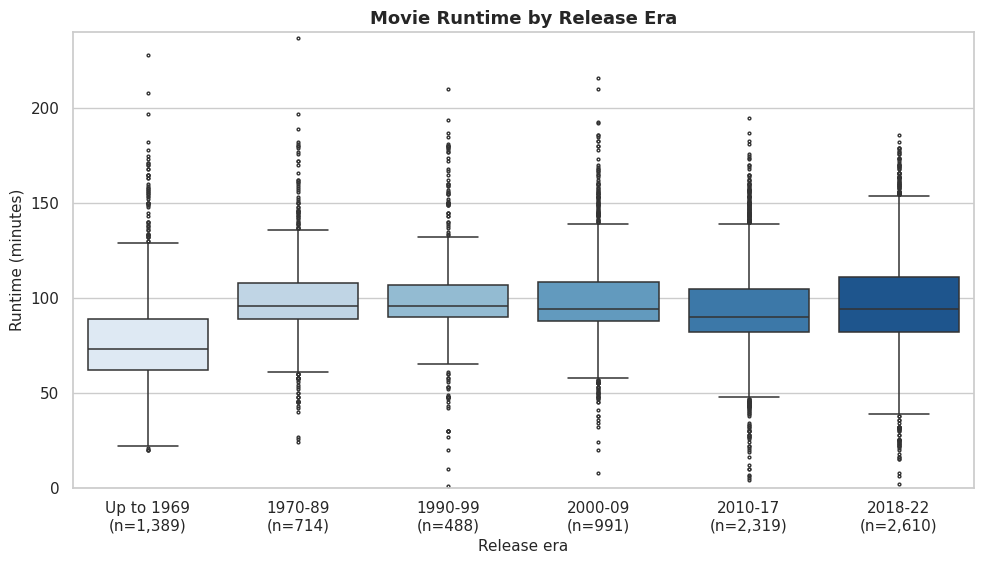

,n,median,mean,p90,share_under_60_%
era,,,,,
Up to 1969,1389,73.00,78.80,105.00,18.00
1970-89,714,96.00,100.40,133.00,4.20
1990-99,488,96.00,100.70,140.00,5.90
2000-09,991,94.00,99.20,135.00,5.20
2010-17,2319,90.00,93.90,128.20,8.60
2018-22,2610,94.00,97.20,135.00,7.60


Movies under 40 min by era: {'Up to 1969': 8, '1970-89': 3, '1990-99': 9, '2000-09': 8, '2010-17': 34, '2018-22': 46}


In [28]:
plot_box(movies, "era", "runtime", "Movie Runtime by Release Era", "Release era", "Runtime (minutes)", "17_movie_runtime_by_era",
         order=ERA_LABELS, ylim=(0, 240), figsize=(10, 5.8), palette=dict(zip(ERA_LABELS, sns.color_palette("Blues", 6))))

by_era = movies.groupby("era", observed=True)["runtime"].agg(n="count", median="median", mean="mean", p90=lambda s: s.quantile(.9))
by_era["share_under_60_%"] = movies.groupby("era", observed=True)["runtime"].apply(lambda s: (s < 60).mean() * 100)
display(by_era.loc[ERA_LABELS].round(1))
print("Movies under 40 min by era:", movies[movies["runtime"] < 40].groupby("era", observed=True).size().to_dict())


**Why this chart:** Runtime by era shows whether modern films are getting longer, shorter or more varied. Only movies are used, because show runtimes are per episode.

**Insight:** Films up to 1969 are noticeably shorter, with a median of 73 minutes and 18.0% under 60 minutes. Every era since 1970 sits between 90 and 96 minutes, with 90 for 2010–17 and 94 for 2018–22. Very short films (under 40 minutes) have become more common: 8 up to 1969, 34 in 2010–17 and 46 in 2018–22, so 80 of the 108 short movies come from the last two eras.

**Business impact:** Mixed. Modern shorts add variety, but they can distort average runtime and confuse viewers who expect a feature. Action: create a separate shorts category and report runtime statistics for features only.

## 12. Bivariate analysis — numerical vs numerical

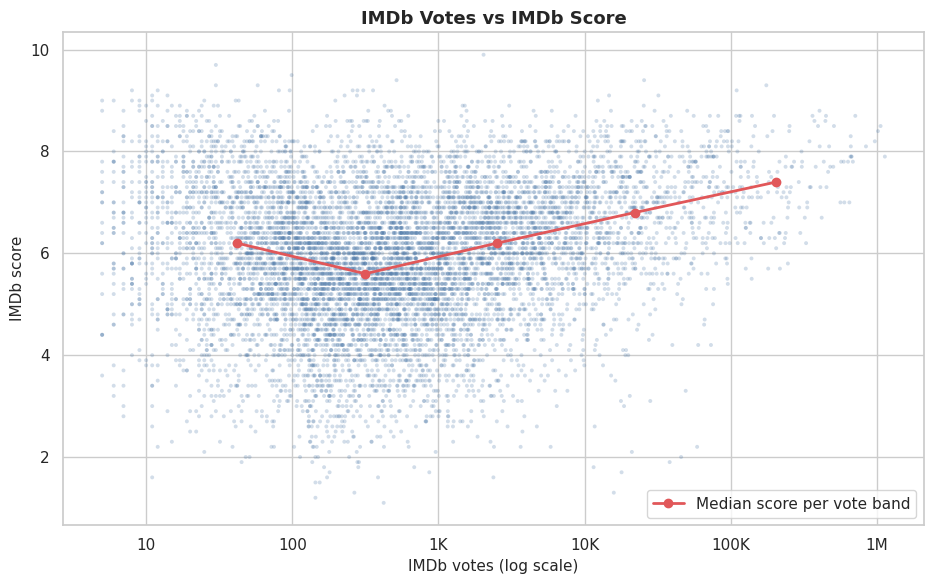

Rows: 8,837 | Spearman correlation (votes, score): 0.143


,n,median,mean,share_strong_%,share_poor_%
vote_band,,,,,
<100,1973,6.20,6.10,31.10,19.00
100-999,3636,5.60,5.60,14.70,28.50
1K-9.9K,2294,6.20,6.10,24.90,17.30
10K-99K,781,6.80,6.70,47.20,5.80
100K+,153,7.40,7.40,71.90,0.00


Score std dev: under 100 votes 1.41 | 10K+ votes 1.15


In [29]:
d = scored.dropna(subset=["imdb_votes"])
d = d[d["imdb_votes"] > 0]
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(d["imdb_votes"], d["imdb_score"], s=8, alpha=0.25, color=BASE_COLOR, edgecolors="none")
vb = d.groupby("vote_band", observed=True).agg(x=("imdb_votes", "median"), y=("imdb_score", "median"), n=("imdb_score", "count"))
ax.plot(vb["x"], vb["y"], color="#E15759", marker="o", lw=2, label="Median score per vote band")
ax.set_xscale("log")
humanize_axis(ax, "x")
ax.set(title="IMDb Votes vs IMDb Score", xlabel="IMDb votes (log scale)", ylabel="IMDb score")
ax.legend(frameon=True, loc="lower right")
fig.tight_layout()
save_fig(fig, "18_votes_vs_score")

print(f"Rows: {len(d):,} | Spearman correlation (votes, score): {d['imdb_votes'].corr(d['imdb_score'], method='spearman'):.3f}")
vb2 = d.groupby("vote_band", observed=True)["imdb_score"].agg(n="count", median="median", mean="mean")
vb2["share_strong_%"] = d.groupby("vote_band", observed=True)["imdb_score"].apply(lambda s: (s >= 7).mean() * 100)
vb2["share_poor_%"] = d.groupby("vote_band", observed=True)["imdb_score"].apply(lambda s: (s < 5).mean() * 100)
display(vb2.round(1))
print(f"Score std dev: under 100 votes {d.loc[d['imdb_votes'] < 100, 'imdb_score'].std():.2f} | 10K+ votes {d.loc[d['imdb_votes'] >= 10_000, 'imdb_score'].std():.2f}")


**Why this chart:** If popular titles are also better, votes should predict score. A scatter of votes (log axis) against score, with the median per vote band, tests this.

**Insight:** The relationship is weak (rank correlation 0.14 over 8,837 titles). Median score by vote band runs 6.2 for under 100 votes, 5.6 for 100–999, 6.2 for 1K–9.9K, 6.8 for 10K–99K and 7.4 for 100K or more. Titles with 100K or more votes are 71.9% strong and none is poor, while the 10K–99K group is 47.2% strong and 5.8% poor. Scores based on under 100 votes are the least stable: their standard deviation is 1.41 against 1.15 for titles with 10K or more votes.

**Business impact:** Mixed. Very well-known titles are better on average, but fame is not a reliable quality signal for the other 99% of the library. Action: keep the minimum-votes rule for rankings, and do not read a high score from a handful of votes as proof of quality.

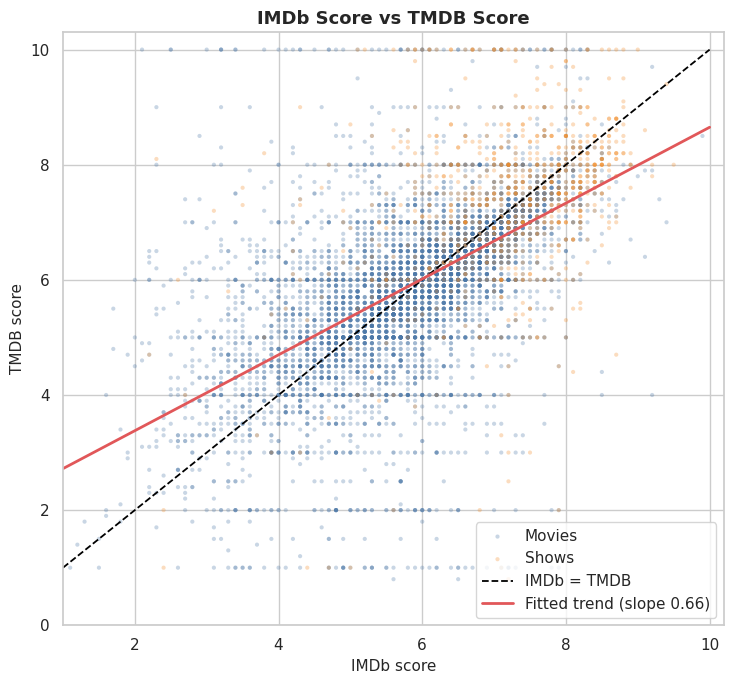

Titles with both scores: 7,319 | Pearson: 0.581 | Spearman: 0.645
Mean gap (IMDb - TMDB): -0.04 | median absolute gap: 0.50 | within +/-1 point: 71.9% | 2 or more points apart: 768 (10.5%)
Mean gap by type: {'MOVIE': -0.02, 'SHOW': -0.15}
On reliable scores only (>= 100 votes): Spearman 0.689 | TMDB is missing for 21.1% of all titles


In [30]:
both = titles.dropna(subset=["imdb_score", "tmdb_score"])
fig, ax = plt.subplots(figsize=(7.5, 7))
for t in TYPE_ORDER:
    sub = both[both["type"] == t]
    ax.scatter(sub["imdb_score"], sub["tmdb_score"], s=9, alpha=0.3, color=PALETTE_TYPE[t], edgecolors="none", label=f"{t.title()}s")
ax.plot([1, 10], [1, 10], color="black", ls="--", lw=1.3, label="IMDb = TMDB")
slope, intercept = np.polyfit(both["imdb_score"], both["tmdb_score"], 1)
ax.plot([1, 10], [intercept + slope, intercept + 10 * slope], color="#E15759", lw=2, label=f"Fitted trend (slope {slope:.2f})")
ax.set(title="IMDb Score vs TMDB Score", xlabel="IMDb score", ylabel="TMDB score", xlim=(1, 10.2), ylim=(0, 10.3))
ax.legend(frameon=True, loc="lower right")
fig.tight_layout()
save_fig(fig, "19_imdb_vs_tmdb_score")

gap_ = both["imdb_score"] - both["tmdb_score"]
print(f"Titles with both scores: {len(both):,} | Pearson: {both['imdb_score'].corr(both['tmdb_score']):.3f} | Spearman: {both['imdb_score'].corr(both['tmdb_score'], method='spearman'):.3f}")
print(f"Mean gap (IMDb - TMDB): {gap_.mean():+.2f} | median absolute gap: {gap_.abs().median():.2f} | within +/-1 point: {(gap_.abs() <= 1).mean():.1%} | 2 or more points apart: {(gap_.abs() >= 2).sum()} ({(gap_.abs() >= 2).mean():.1%})")
print("Mean gap by type:", both.assign(g=gap_).groupby("type")["g"].mean().round(2).to_dict())
print(f"On reliable scores only (>= {MIN_VOTES} votes): Spearman {rel.dropna(subset=['tmdb_score'])['imdb_score'].corr(rel['tmdb_score'], method='spearman'):.3f} | TMDB is missing for {titles['tmdb_score'].isna().mean():.1%} of all titles")


**Why this chart:** IMDb and TMDB are independent audience sources. If they agree, quality findings are more trustworthy; if not, one of them needs a cross-check.

**Insight:** 7,319 titles have both scores. The rank correlation is 0.645 (Pearson 0.581), 71.9% of titles are within 1 point of each other, and the median absolute gap is 0.50. There is no overall bias (mean gap −0.04), though TMDB scores shows slightly higher (−0.15). 768 titles (10.5%) differ by 2 points or more. On IMDb scores with at least 100 votes the agreement is stronger (rank correlation 0.689), and TMDB is missing for 21.1% of titles. The horizontal bands at 1 and 10 show TMDB scores at the extremes.

**Business impact:** Positive. Two sources broadly agree, which supports the quality tiers used in this project. Action: use IMDb as the primary score and TMDB as a cross-check, and send titles that differ by 2 or more points for review (Part B shows that many of the largest disagreements involve titles with very few votes).

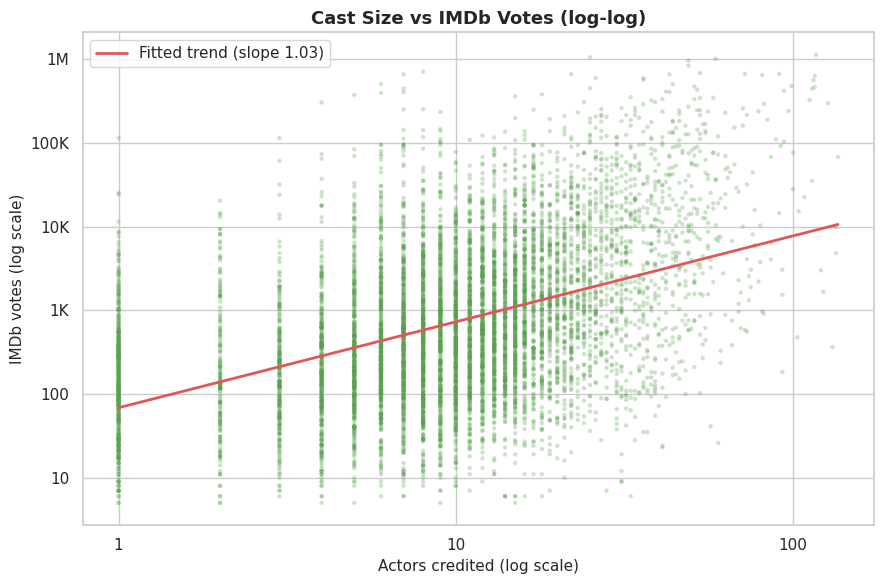

{'n': 7952, 'slope': 1.027, 'spearman': 0.43}


,n,median_votes,median_score,median_popularity
cast_band,,,,
1-5,1624,178.00,6.40,1.65
6-10,2311,415.00,5.80,2.48
11-20,2606,815.50,5.80,3.25
21+,1411,"3,476.00",6.20,6.47


Spearman(cast size, IMDb score): -0.035 | Spearman(cast size, popularity): 0.364
Median cast size for strong (7+) / average / poor titles: {'Poor (<5)': 10.0, 'Average (5-6.9)': 12.0, 'Strong (7+)': 8.0}


In [31]:
cv = titles[(titles["cast_size"] > 0) & (titles["imdb_votes"] > 0)]
stats = loglog_scatter(cv, "cast_size", "imdb_votes", "Cast Size vs IMDb Votes (log-log)", "Actors credited (log scale)", "IMDb votes (log scale)",
                       "20_cast_size_vs_votes", color="#59A14F")
print({k: round(v, 3) for k, v in stats.items()})
cb = cv.assign(cast_band=pd.cut(cv["cast_size"], [0, 5, 10, 20, 500], labels=["1-5", "6-10", "11-20", "21+"]))
cb_stats = cb.groupby("cast_band", observed=True).agg(n=("id", "count"), median_votes=("imdb_votes", "median"), median_score=("imdb_score", "median"), median_popularity=("tmdb_popularity", "median"))
display(cb_stats.round(2))
print(f"Spearman(cast size, IMDb score): {cv['cast_size'].corr(cv['imdb_score'], method='spearman'):.3f} | Spearman(cast size, popularity): {cv['cast_size'].corr(cv['tmdb_popularity'], method='spearman'):.3f}")
print("Median cast size for strong (7+) / average / poor titles:", cv.groupby("quality_tier", observed=True)["cast_size"].median().reindex(TIER_ORDER).to_dict())


**Why this chart:** Big casts are often assumed to draw audiences. A log-log scatter of cast size against votes tests whether that holds.

**Insight:** Votes rise roughly in proportion to cast size (fitted slope 1.03, rank correlation 0.43 over 7,952 titles). Median votes climb from 178 for casts of 1–5 to 415 for 6–10, about 816 for 11–20 and 3,476 for 21 or more, and median popularity from 1.65 to 6.47. Cast size does not help quality: the rank correlation with IMDb score is −0.035, and median scores are 6.4, 5.8, 5.8 and 6.2 across the four cast bands. Strong titles have a median cast of 8 against 12 for average titles.

**Business impact:** Mixed. A large cast is a visibility signal, not a quality signal. It may also reflect how completely credits were recorded. Action: do not use cast size to judge quality, and use it only as one input when estimating audience reach.

## 13. Bivariate analysis — categorical vs categorical

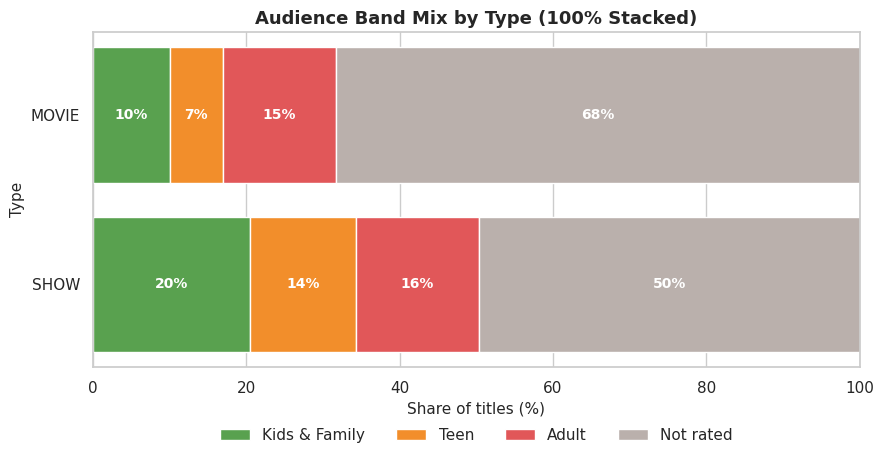

audience_band,Kids & Family,Teen,Adult,Not rated
type,,,,
MOVIE,10.00,6.90,14.80,68.30
SHOW,20.50,13.90,16.00,49.70


Mix among rated titles only (%):


audience_band,Kids & Family,Teen,Adult
type,,,
MOVIE,31.50,21.80,46.70
SHOW,40.70,27.50,31.80


Rated titles by type: {'MOVIE': 2701, 'SHOW': 683}
Share of MOVIES / SHOWS that are Adult-rated among ALL titles: {'MOVIE': 14.8, 'SHOW': 16.0}


In [32]:
ct_band = pd.crosstab(titles["type"], titles["audience_band"], normalize="index").loc[TYPE_ORDER, BAND_ORDER]
plot_stacked_pct(ct_band, "Audience Band Mix by Type (100% Stacked)", "Type", "21_audience_band_by_type", BAND_ORDER, PALETTE_BAND, figsize=(9, 4.8))
display((ct_band * 100).round(1))

rated_only = titles[titles["audience_band"] != "Not rated"]
ct_rated = pd.crosstab(rated_only["type"], rated_only["audience_band"], normalize="index").loc[TYPE_ORDER, BAND_ORDER[:3]]
print("Mix among rated titles only (%):")
display((ct_rated * 100).round(1))
print("Rated titles by type:", rated_only["type"].value_counts().to_dict())
print("Share of MOVIES / SHOWS that are Adult-rated among ALL titles:", (ct_band["Adult"] * 100).round(1).to_dict())


**Why this chart:** Two categorical variables, type and audience band, are best compared as shares. A 100% stacked bar removes the effect of the very different number of movies and shows.

**Insight:** 68.3% of movies are unrated against 49.7% of shows. Among all titles, movies are 10.0% Kids & Family, 6.9% Teen and 14.8% Adult, and shows are 20.5%, 13.9% and 16.0%. Among rated titles only (2,701 movies and 683 shows), movies skew adult (46.7% adult, 31.5% kids and family, 21.8% teen) while shows skew towards families (40.7% kids and family, 27.5% teen, 31.8% adult).

**Business impact:** Mixed. Rated shows are a friendlier mix for family viewing, but the large unrated block makes any audience split unreliable, especially for movies. Action: complete movie certifications first, then re-check the audience mix.

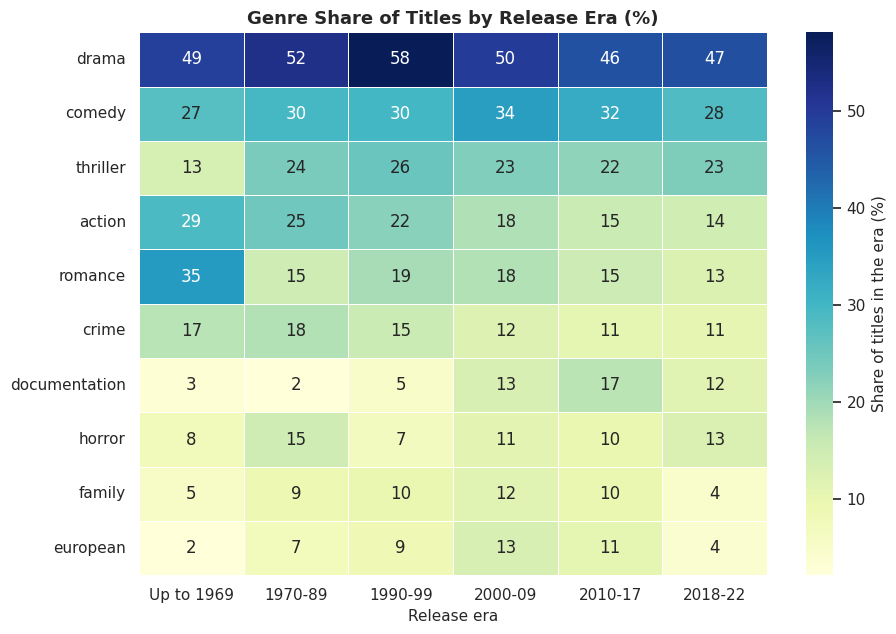

Titles per era: {'Up to 1969': 1412, '1970-89': 763, '1990-99': 546, '2000-09': 1189, '2010-17': 2823, '2018-22': 3135}


era,Up to 1969,1970-89,1990-99,2000-09,2010-17,2018-22
genre,,,,,,
drama,49.00,52.30,58.10,49.50,46.20,46.60
comedy,27.50,29.60,29.90,34.50,32.20,28.40
thriller,13.40,23.60,25.60,23.00,21.70,23.10
action,29.00,24.90,22.20,18.30,15.30,14.40
romance,35.10,14.90,19.20,18.20,15.10,12.50
crime,17.40,18.20,15.40,12.40,10.70,10.60
documentation,3.00,2.10,5.10,13.10,17.40,11.60
horror,7.60,14.80,6.80,11.00,9.80,12.70
family,5.30,8.90,9.90,11.50,9.80,4.50


Change in share, 2018-22 vs up to 1969 (points): {'romance': -22.6, 'action': -14.6, 'crime': -6.9, 'drama': -2.4, 'family': -0.8, 'comedy': 0.9, 'european': 1.7, 'horror': 5.1, 'documentation': 8.6, 'thriller': 9.7}


In [33]:
top10_g = list(genre_long["genre"].value_counts().head(10).index)
era_totals = titles["era"].value_counts()
gh = pd.crosstab(genre_long["genre"], genre_long["era"]).reindex(index=top10_g, columns=ERA_LABELS)
gh = gh.div(era_totals.reindex(ERA_LABELS), axis=1) * 100

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.grid(False)
sns.heatmap(gh, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, linecolor="white", cbar_kws={"label": "Share of titles in the era (%)"}, ax=ax)
ax.set(title="Genre Share of Titles by Release Era (%)", xlabel="Release era", ylabel="")
fig.tight_layout()
save_fig(fig, "22_genre_by_era_heatmap")

print("Titles per era:", era_totals.reindex(ERA_LABELS).to_dict())
display(gh.round(1))
chg = (gh["2018-22"] - gh["Up to 1969"]).sort_values()
print("Change in share, 2018-22 vs up to 1969 (points):", chg.round(1).to_dict())


**Why this chart:** The genre mix of the catalogue has changed over time. A heatmap of genre share by release era shows what the library has been adding.

**Insight:** Romance fell from 35% of titles up to 1969 to 13% in 2018–22 (−22.6 points) and action from 29% to 14% (−14.6). Thriller rose from 13% to 23% (+9.7), documentary from 3% to 12% (+8.6, with a peak of 17% in 2010–17) and horror from 8% to 13% (+5.1). Drama stays the anchor in every era, between 46% and 58%. Family content is thinnest in the newest era at 4.5%, down from 11.5% in 2000–09, and European titles fall from 13.1% to 3.9%.

**Business impact:** Mixed. The recent mix has moved towards documentary, which is high quality, and towards thriller and horror, which are the weakest genres for quality (chart 14). Family content is the clearest gap. Action: rebalance new additions towards documentary and family, and apply quality gates to thriller and horror.

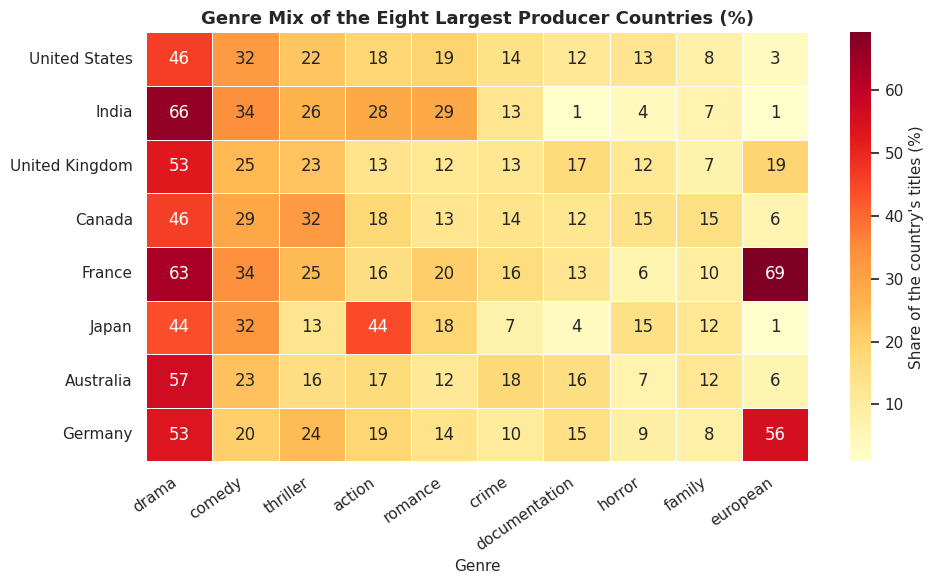

genre,drama,comedy,thriller,action,romance,crime,documentation,horror,family,european
country,,,,,,,,,,
United States,46.20,32.10,22.40,18.30,19.20,14.30,11.70,12.80,7.90,3.50
India,66.00,34.30,26.30,28.50,28.80,13.10,1.10,4.00,6.60,0.90
United Kingdom,52.90,25.10,23.00,13.40,12.20,12.60,16.90,12.30,7.10,18.90
Canada,46.00,29.10,31.90,18.10,13.00,13.60,12.50,14.50,15.10,6.20
France,63.20,34.00,24.80,15.60,20.40,16.40,12.80,6.40,9.60,69.20
Japan,43.70,32.50,12.70,44.20,18.30,7.10,3.60,14.70,12.20,1.00
Australia,56.60,23.10,15.60,16.80,11.60,17.90,15.60,6.90,12.10,5.80
Germany,53.50,20.30,24.40,18.60,14.00,10.50,14.50,8.70,8.10,55.80


Titles per country: {'United States': 5331, 'India': 1072, 'United Kingdom': 928, 'Canada': 530, 'France': 250, 'Japan': 197, 'Australia': 173, 'Germany': 172}
drama          highest: India (66%) | lowest: Japan (44%)
comedy         highest: India (34%) | lowest: Germany (20%)
documentation  highest: United Kingdom (17%) | lowest: India (1%)
romance        highest: India (29%) | lowest: Australia (12%)
action         highest: Japan (44%) | lowest: United Kingdom (13%)
horror         highest: Japan (15%) | lowest: India (4%)


In [34]:
top_c = [c for c in country_long["country_code"].value_counts().index if c != "XX"][:8]
cl = country_long[country_long["country_code"].isin(top_c)][["id", "country_code", "country"]]
cg = cl.merge(genre_long[["id", "genre"]], on="id")
ch_ = pd.crosstab(cg["country"], cg["genre"]).reindex(columns=top10_g)
c_totals = cl.groupby("country")["id"].nunique()
ch_ = ch_.div(c_totals, axis=0).mul(100).loc[[country_name(c) for c in top_c]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(False)
sns.heatmap(ch_, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, linecolor="white", cbar_kws={"label": "Share of the country's titles (%)"}, ax=ax)
ax.set(title="Genre Mix of the Eight Largest Producer Countries (%)", xlabel="Genre", ylabel="")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.tight_layout()
save_fig(fig, "23_country_genre_heatmap")

display(ch_.round(1))
print("Titles per country:", c_totals.loc[[country_name(c) for c in top_c]].to_dict())
for g in ["drama", "comedy", "documentation", "romance", "action", "horror"]:
    row = ch_[g]
    print(f"{g:14s} highest: {row.idxmax()} ({row.max():.0f}%) | lowest: {row.idxmin()} ({row.min():.0f}%)")


**Why this chart:** Countries specialise. A heatmap of genre share for the eight biggest producer countries shows which regions are strongest for which kinds of content.

**Insight:** India is 66% drama, 29% romance and 28.5% action but only 1.1% documentary and 4.0% horror. Japan is 44.2% action, the highest of any country, with just 12.7% thriller. France (69.2%) and Germany (55.8%) carry most of the 'european' label. The United Kingdom has the most documentaries (16.9%), Canada the most thrillers (31.9%) and family titles (15.1%), and the United States, at 46.2% drama and 32.1% comedy, looks close to the catalogue average.

**Business impact:** Positive for targeted sourcing. Action: source action from Japan, documentaries from the United Kingdom, Australia and Germany, and drama and romance from India, then check the quality gate for each source.

## 14. Multivariate analysis

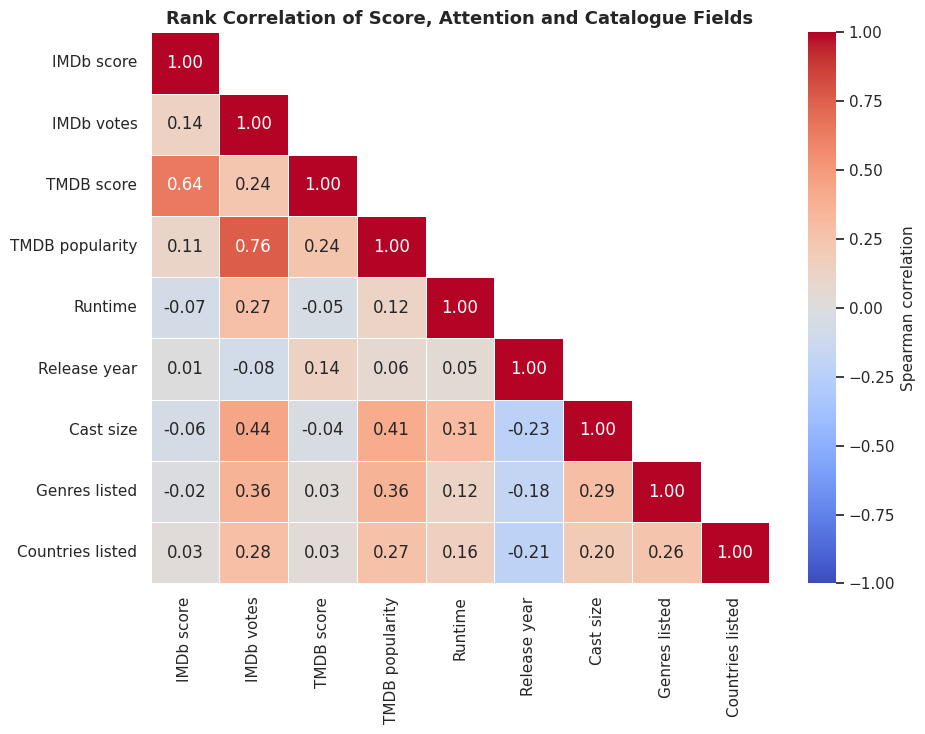

Correlation with IMDb score:
 IMDb votes          0.14
TMDB score          0.64
TMDB popularity     0.11
Runtime            -0.07
Release year        0.01
Cast size          -0.06
Genres listed      -0.02
Countries listed    0.03
IMDb votes vs TMDB popularity: 0.76
TMDB score vs IMDb score: 0.64
Cast size vs IMDb votes: 0.44
Cast size vs TMDB popularity: 0.41
Release year vs TMDB popularity: 0.06
Release year vs IMDb votes: -0.08
Runtime vs IMDb score: -0.07
Genres listed vs IMDb votes: 0.36


In [35]:
corr_cols = {"imdb_score": "IMDb score", "imdb_votes": "IMDb votes", "tmdb_score": "TMDB score", "tmdb_popularity": "TMDB popularity",
             "runtime": "Runtime", "release_year": "Release year", "cast_size": "Cast size", "n_genres": "Genres listed", "n_countries": "Countries listed"}
# Spearman (rank) correlation because votes, popularity and cast size are heavily right-skewed.
# Titles with no credit rows have an unknown (not zero) cast size, so they are left out of the cast-size correlations.
corr_src = titles.assign(cast_size=titles["cast_size"].where(titles["has_credits"] == 1))
corr = corr_src[list(corr_cols)].rename(columns=corr_cols).corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.grid(False)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Spearman correlation"}, ax=ax)
ax.set(title="Rank Correlation of Score, Attention and Catalogue Fields")
fig.tight_layout()
save_fig(fig, "24_correlation_heatmap")

print("Correlation with IMDb score:\n", corr["IMDb score"].drop("IMDb score").round(2).to_string())
for a, b in [("IMDb votes", "TMDB popularity"), ("TMDB score", "IMDb score"), ("Cast size", "IMDb votes"), ("Cast size", "TMDB popularity"),
             ("Release year", "TMDB popularity"), ("Release year", "IMDb votes"), ("Runtime", "IMDb score"), ("Genres listed", "IMDb votes")]:
    print(f"{a} vs {b}: {corr.loc[a, b]:.2f}")


**Why this chart:** A correlation heatmap summarises how all numeric fields move together. Rank (Spearman) correlation is used because votes, popularity and cast size are heavily skewed. Titles with no credits are left out of the cast-size correlations.

**Insight:** Attention variables move together: votes and popularity 0.76, cast size with votes 0.44 and with popularity 0.41, and genres listed with votes 0.36. Quality is linked to almost nothing except the other score: TMDB score 0.64, votes 0.14, popularity 0.11, and then runtime −0.07, cast size −0.06, genres listed −0.02 and release year 0.01. Newer titles are not systematically more or less popular (release year against popularity 0.06).

**Business impact:** Neutral to positive. Simple catalogue attributes such as year, runtime or cast size do not predict quality, which is why type, genre and country matter more (charts 13–15). Action: use categorical features for any model, and keep only one of votes and popularity since they carry the same information.

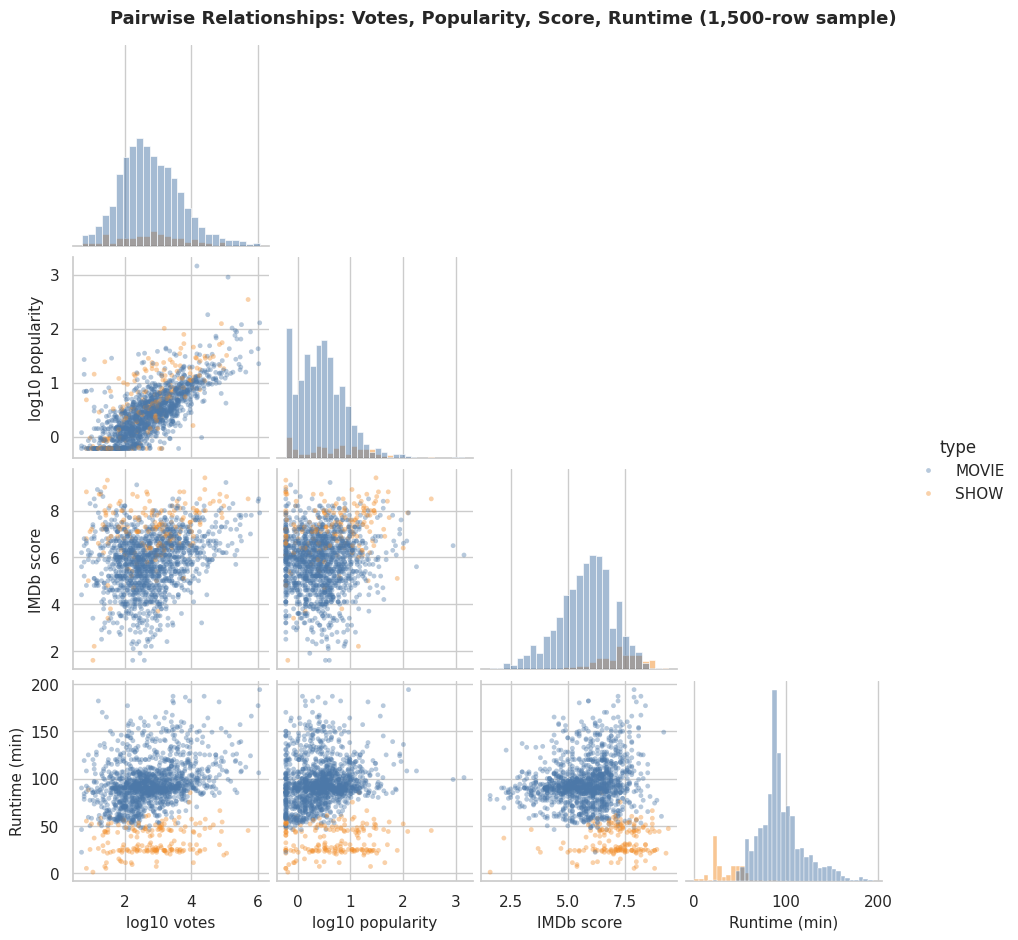

Rows with all four fields: 8,509 | sampled: 1,500
                  log10 votes  log10 popularity  IMDb score  Runtime (min)
log10 votes              1.00              0.76        0.18           0.28
log10 popularity         0.76              1.00        0.11           0.11
IMDb score               0.18              0.11        1.00          -0.07
Runtime (min)            0.28              0.11       -0.07           1.00
Median runtime by type in the sample: {'MOVIE': 91.0, 'SHOW': 30.0}


In [36]:
pair_cols = {"log10_votes": "log10 votes", "log10_popularity": "log10 popularity", "imdb_score": "IMDb score", "runtime": "Runtime (min)"}
pair = titles[list(pair_cols) + ["type"]].dropna().rename(columns=pair_cols)
pair = pair[pair["Runtime (min)"] <= 240]
pair_sample = pair.sample(1500, random_state=SEED)      # sampled so the grid stays fast and readable

g = sns.pairplot(pair_sample, hue="type", hue_order=TYPE_ORDER, palette=PALETTE_TYPE, corner=True, diag_kind="hist", height=2.3,
                 plot_kws={"alpha": 0.4, "s": 12, "edgecolor": "none"})
g.figure.suptitle("Pairwise Relationships: Votes, Popularity, Score, Runtime (1,500-row sample)", y=1.02, fontsize=13, fontweight="bold")
save_fig(g.figure, "25_pairplot_key_metrics")

print(f"Rows with all four fields: {len(pair):,} | sampled: {len(pair_sample):,}")
print(pair.drop(columns="type").corr(method="spearman").round(2).to_string())
print("Median runtime by type in the sample:", pair_sample.groupby("type")["Runtime (min)"].median().to_dict())


**Why this chart:** A pairplot shows several relationships at once and reveals shape, clusters and outliers. Log10 values and a 1,500-row sample keep it readable and fast, and colour separates movies from shows.

**Insight:** Using the 8,509 titles that have all four fields, votes and popularity are tightly linked on the log scale (0.76), and runtime has a moderate link with votes (0.28). IMDb score is only loosely related to anything else: 0.18 with log votes, 0.11 with log popularity and −0.07 with runtime. Movies and shows form two clear groups: shows cluster below about 60 minutes (sample median 30) and towards higher scores, movies around 91 minutes across a wide score range.

**Business impact:** Positive. Because votes and popularity carry nearly the same signal, one attention measure is enough for reporting. Action: keep type as a core feature in every analysis, since runtime and score both split by it.

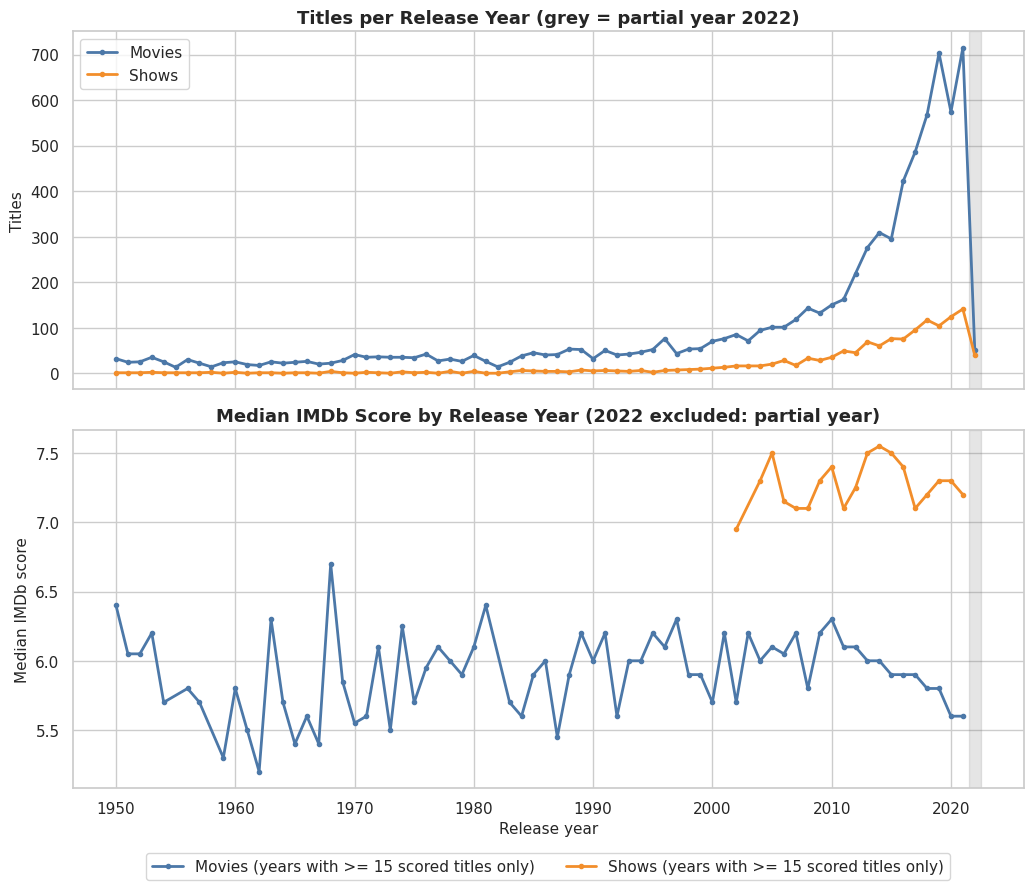

Titles per year (last 8 years): {2015: 371, 2016: 497, 2017: 581, 2018: 685, 2019: 807, 2020: 698, 2021: 856, 2022: 89}
Peak year: 2021 (856 titles) | share of all titles released 2015-2021: 45.6%
Shows per year: 2000 11 -> 2019 104 -> 2021 141 | Movies: 2000 70 -> 2019 703 -> 2021 715
Show share of titles by era: {'Up to 1969': 1.6, '1970-89': 6.4, '1990-99': 10.6, '2000-09': 16.7, '2010-17': 17.9, '2018-22': 16.7}
Median IMDb score by era and type:


type,MOVIE,SHOW
era,,
Up to 1969,5.80,7.70
1970-89,5.90,7.40
1990-99,6.00,7.35
2000-09,6.00,7.10
2010-17,6.00,7.40
2018-22,5.70,7.20


In [37]:
yr = titles[titles["release_year"] >= 1950].groupby(["release_year", "type"]).size().unstack(fill_value=0).reindex(columns=TYPE_ORDER)
ys = (scored[scored["release_year"].between(1950, LAST_FULL_YEAR)].groupby(["release_year", "type"])["imdb_score"].agg(n="count", med="median").reset_index().query("n >= 15"))

fig, axes = plt.subplots(2, 1, figsize=(10.5, 9), sharex=True)
for t in TYPE_ORDER:
    axes[0].plot(yr.index, yr[t], color=PALETTE_TYPE[t], marker="o", ms=3, lw=2, label=f"{t.title()}s")
    sub = ys[ys["type"] == t]
    axes[1].plot(sub["release_year"], sub["med"], color=PALETTE_TYPE[t], marker="o", ms=3, lw=2, label=f"{t.title()}s (years with >= 15 scored titles only)")
for ax in axes:
    ax.axvspan(LAST_FULL_YEAR + 0.5, 2022.5, color="grey", alpha=0.2)
axes[0].set(title="Titles per Release Year (grey = partial year 2022)", ylabel="Titles")
axes[1].set(title="Median IMDb Score by Release Year (2022 excluded: partial year)", xlabel="Release year", ylabel="Median IMDb score")
axes[0].legend(frameon=True)
axes[1].legend(frameon=True, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.tight_layout()
save_fig(fig, "26_yearly_trend_by_type")

print("Titles per year (last 8 years):", yr.assign(total=yr.sum(axis=1)).tail(8)["total"].to_dict())
print(f"Peak year: {yr.sum(axis=1).idxmax()} ({yr.sum(axis=1).max():,} titles) | share of all titles released 2015-2021: {titles['release_year'].between(2015, 2021).mean():.1%}")
print(f"Shows per year: 2000 {yr.loc[2000, 'SHOW']} -> 2019 {yr.loc[2019, 'SHOW']} -> 2021 {yr.loc[2021, 'SHOW']} | Movies: 2000 {yr.loc[2000, 'MOVIE']} -> 2019 {yr.loc[2019, 'MOVIE']} -> 2021 {yr.loc[2021, 'MOVIE']}")
print("Show share of titles by era:", (titles.groupby("era", observed=True)["is_show"].mean() * 100).round(1).to_dict())
print("Median IMDb score by era and type:")
display(scored.groupby(["era", "type"], observed=True)["imdb_score"].median().unstack().reindex(ERA_LABELS).round(2))


**Why this chart:** A trend by release year shows whether the catalogue is growing, which format is driving the growth, and whether quality is improving. The score panel leaves out 2022 and any year with fewer than 15 scored titles.

**Insight:** Releases per year rose from a few dozen in the 1950s to 807 in 2019, dipped to 698 in 2020 and peaked at 856 in 2021 (2022 has only 89 because it is a partial year). Shows grew from 11 titles in 2000 to 104 in 2019 and 141 in 2021, and movies from 70 to 703 and 715. The 2015–2021 releases are 45.6% of all titles. Quality has not risen with volume: median movie scores stay between 5.7 and 6.0 in every era, and the newest era (2018–22) is the lowest at 5.7, while shows stay between 7.1 and 7.7.

**Business impact:** Negative for movie quality. More titles have not meant better titles. Action: apply a quality gate to new movie additions, and treat the 2018–22 movie median of 5.7 as the level to beat.

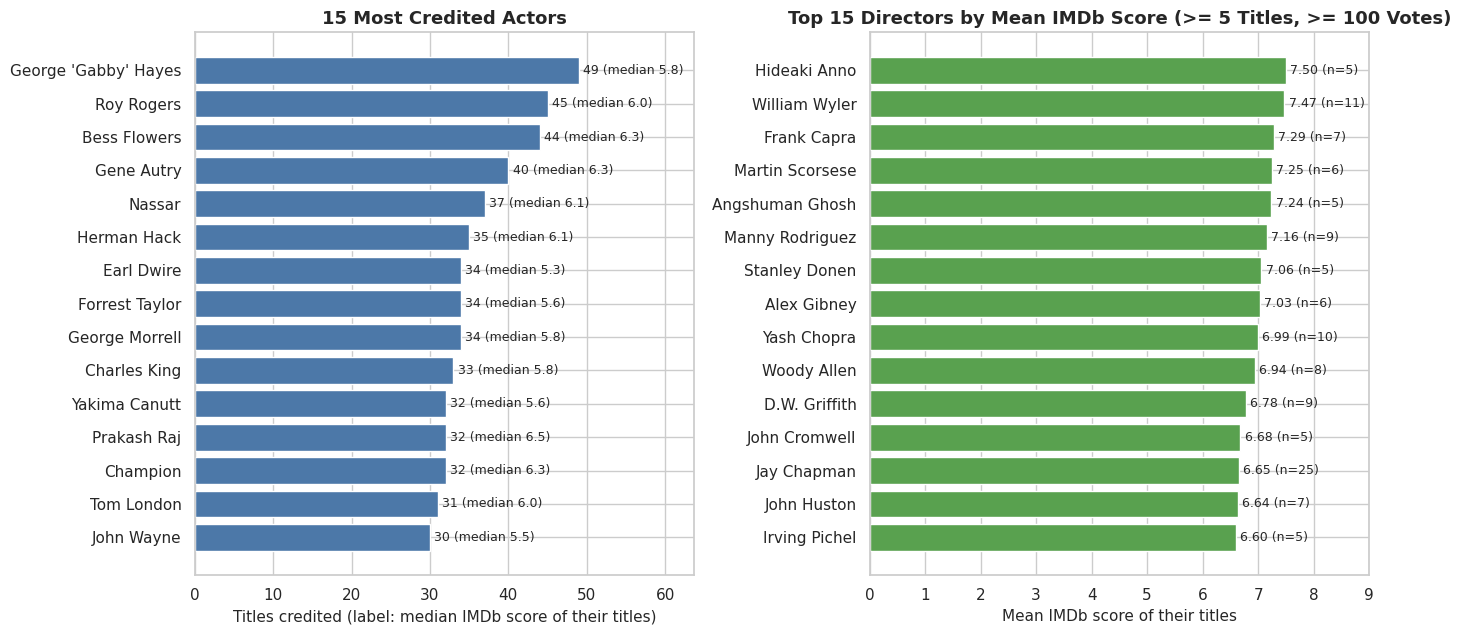

Most credited actors: [{'name': "George 'Gabby' Hayes", 'titles': 49}, {'name': 'Roy Rogers', 'titles': 45}, {'name': 'Bess Flowers', 'titles': 44}, {'name': 'Gene Autry', 'titles': 40}, {'name': 'Nassar', 'titles': 37}]
Top directors: [{'name': 'Hideaki Anno', 'titles': 5, 'mean_score': 7.5}, {'name': 'William Wyler', 'titles': 11, 'mean_score': 7.47}, {'name': 'Frank Capra', 'titles': 7, 'mean_score': 7.29}, {'name': 'Martin Scorsese', 'titles': 6, 'mean_score': 7.25}, {'name': 'Angshuman Ghosh', 'titles': 5, 'mean_score': 7.24}]
Directors with >= 5 reliable titles: 70 | their mean of means: 5.76 | overall reliable mean score: 5.93
People credited as both actor and director: 996 | directors overall: 6,304
Top 1% of people (by titles) account for 8.2% of title-person links


In [38]:
person_name = credits.drop_duplicates("person_id").set_index("person_id")["name"]
work = credits.merge(titles[["id", "imdb_score", "imdb_votes", "type"]], on="id")
work_rel = work[work["imdb_votes"] >= MIN_VOTES]

actors = (work[work["role"] == "ACTOR"].groupby("person_id").agg(titles=("id", "nunique"), median_score=("imdb_score", "median")).nlargest(15, "titles"))
actors["name"] = actors.index.map(person_name)
dirs_ = (work_rel[work_rel["role"] == "DIRECTOR"].groupby("person_id").agg(titles=("id", "nunique"), mean_score=("imdb_score", "mean")).query("titles >= 5")
         .nlargest(15, "mean_score"))
dirs_["name"] = dirs_.index.map(person_name)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
axes[0].barh(actors["name"], actors["titles"], color=BASE_COLOR)
axes[0].invert_yaxis()
axes[0].bar_label(axes[0].containers[0], labels=[f"{t} (median {m:.1f})" for t, m in zip(actors["titles"], actors["median_score"])], padding=3, fontsize=9)
axes[0].set(title="15 Most Credited Actors", xlabel="Titles credited (label: median IMDb score of their titles)", ylabel="")
axes[0].margins(x=0.3)
axes[1].barh(dirs_["name"], dirs_["mean_score"], color="#59A14F")
axes[1].invert_yaxis()
axes[1].bar_label(axes[1].containers[0], labels=[f"{m:.2f} (n={t})" for m, t in zip(dirs_["mean_score"], dirs_["titles"])], padding=3, fontsize=9)
axes[1].set(title="Top 15 Directors by Mean IMDb Score (>= 5 Titles, >= 100 Votes)", xlabel="Mean IMDb score of their titles", ylabel="")
axes[1].set_xlim(0, dirs_["mean_score"].max() * 1.2)
fig.tight_layout()
save_fig(fig, "27_top_actors_and_directors")

print("Most credited actors:", actors[["name", "titles"]].head(5).to_dict("records"))
print("Top directors:", dirs_[["name", "titles", "mean_score"]].head(5).round(2).to_dict("records"))
elig = work_rel[work_rel["role"] == "DIRECTOR"].groupby("person_id").agg(n=("id", "nunique"), m=("imdb_score", "mean")).query("n >= 5")
print(f"Directors with >= 5 reliable titles: {len(elig)} | their mean of means: {elig['m'].mean():.2f} | overall reliable mean score: {rel['imdb_score'].mean():.2f}")
both_roles = set(credits.loc[credits['role'] == 'ACTOR', 'person_id']) & set(credits.loc[credits['role'] == 'DIRECTOR', 'person_id'])
print(f"People credited as both actor and director: {len(both_roles):,} | directors overall: {credits.loc[credits['role'] == 'DIRECTOR', 'person_id'].nunique():,}")
tc = credits.groupby("person_id")["id"].nunique()
print(f"Top 1% of people (by titles) account for {tc.nlargest(int(len(tc) * .01)).sum() / tc.sum():.1%} of title-person links")


**Why this chart:** People are the second dataset in this project. This chart shows who is most credited and which directors are linked to the highest scores.

**Insight:** The most credited actors are classic-era names rather than modern stars: George 'Gabby' Hayes (49 titles), Roy Rogers (45), Bess Flowers (44) and Gene Autry (40), with Nassar (37) as the top name from India. The median score of the top ten actors' titles ranges from 5.3 to 6.3. Among directors with at least 5 titles with 100 or more votes, Hideaki Anno (7.50), William Wyler (7.47 across 11 titles), Frank Capra (7.29) and Martin Scorsese (7.25) lead. Only 70 directors meet that bar and their average of means is 5.76, a little under the overall 5.93. 996 people are credited as both actor and director, out of 6,304 directors, and the top 1% of people account for only 8.2% of all title-person links.

**Business impact:** Mixed. Volume of credits reflects the classic western and B-film depth of the library, not quality or current popularity. Action: do not rank talent by number of credits, and feature the few directors with a strong, repeated record in curated collections.

# Part B — Supporting tables and investigations
These tables back up the charts but are not charts themselves. Score columns marked *reliable* use only titles with at least 100 IMDb votes.

### Country summary — titles, score and attention

In [39]:
country_summary = (country_long.groupby("country")
    .agg(titles=("id", "nunique"), median_votes=("imdb_votes", "median"), median_popularity=("tmdb_popularity", "median"))
    .join(country_scored.groupby("country")["imdb_score"].median().rename("median_score_reliable"))
    .sort_values("titles", ascending=False))
country_summary["share_of_titles_pct"] = country_summary["titles"] / len(titles) * 100
display(country_summary.head(10))


,titles,median_votes,median_popularity,median_score_reliable,share_of_titles_pct
country,,,,,
United States,5331,518.00,2.79,5.80,54.02
India,1072,694.00,1.58,6.50,10.86
United Kingdom,928,"1,105.00",3.98,6.50,9.40
Canada,530,625.00,3.90,5.70,5.37
France,250,"2,557.00",6.64,6.40,2.53
Japan,197,883.00,7.62,6.90,2.00
Australia,173,481.50,3.55,6.40,1.75
Germany,172,"1,274.00",4.38,6.10,1.74
Italy,143,632.00,3.52,5.90,1.45


### Genre summary

In [40]:
genre_summary = (genre_long.groupby("genre")
    .agg(titles=("id", "nunique"), median_votes=("imdb_votes", "median"), median_popularity=("tmdb_popularity", "median"), median_runtime=("runtime", "median"))
    .join(genre_scored.groupby("genre")["imdb_score"].agg(median_score_reliable="median", scored_titles="count"))
    .sort_values("titles", ascending=False))
genre_summary["strong_share_pct"] = genre_scored.groupby("genre")["imdb_score"].apply(lambda s: (s >= 7).mean() * 100)
genre_summary["poor_share_pct"] = genre_scored.groupby("genre")["imdb_score"].apply(lambda s: (s < 5).mean() * 100)
display(genre_summary)


,titles,median_votes,median_popularity,median_runtime,median_score_reliable,scored_titles,strong_share_pct,poor_share_pct
genre,,,,,,,,
drama,4762,658.50,2.92,94.00,6.20,3656,25.11,14.61
comedy,2987,595.50,2.81,88.00,6.00,2274,22.08,19.22
thriller,2119,"1,143.50",3.75,93.00,5.60,1787,16.00,32.74
action,1820,727.00,3.24,91.00,5.70,1486,18.98,27.39
romance,1751,743.00,2.86,94.00,6.10,1442,20.11,13.87
crime,1250,943.50,3.47,91.00,6.00,1051,23.41,17.13
documentation,1096,188.50,1.80,74.00,7.10,611,57.77,3.60
horror,1065,"1,003.50",3.87,88.00,4.70,887,6.43,57.27
family,751,510.00,3.41,85.00,6.10,577,23.05,16.98


### Type summary — movies vs shows

In [41]:
type_summary = (titles.groupby("type")
    .agg(titles=("id", "count"), median_runtime=("runtime", "median"), median_score=("imdb_score", "median"), median_votes=("imdb_votes", "median"),
         median_popularity=("tmdb_popularity", "median"), pct_rated=("age_certification", lambda s: s.notna().mean() * 100)))
type_summary["median_cast_titles_with_cast"] = titles[titles["cast_size"] > 0].groupby("type")["cast_size"].median()
display(type_summary)


,titles,median_runtime,median_score,median_votes,median_popularity,pct_rated,median_cast_titles_with_cast
type,,,,,,,
MOVIE,8511,91.00,5.90,460.00,2.39,31.74,11.00
SHOW,1357,33.00,7.30,480.50,5.07,50.33,7.00


### Age-certification summary

In [42]:
cert_summary = (titles.assign(age_certification=titles["age_certification"].fillna("Not rated")).groupby("age_certification")
    .agg(titles=("id", "count"), shows=("is_show", "sum"), median_score=("imdb_score", "median"), median_popularity=("tmdb_popularity", "median"), median_year=("release_year", "median"))
    .sort_values("titles", ascending=False))
cert_summary["median_year"] = cert_summary["median_year"].map(lambda v: f"{v:g}")      # keep years free of thousands separators
display(cert_summary)


,titles,shows,median_score,median_popularity,median_year
age_certification,,,,,
Not rated,6484,674,6.00,1.84,2015
R,1249,0,5.80,5.99,2008
PG-13,588,0,6.00,4.72,2011
PG,582,0,6.00,3.56,2009
G,269,0,6.00,2.45,2004
TV-MA,217,217,7.50,14.03,2018
TV-14,188,188,7.25,8.99,2015
TV-PG,91,91,7.40,7.81,2010
TV-Y,78,78,6.60,4.38,2009.5


### Decade summary

In [43]:
decade_summary = (titles.groupby("decade")
    .agg(titles=("id", "count"), shows=("is_show", "sum"), median_score=("imdb_score", "median"), median_runtime=("runtime", "median")))
decade_summary["show_share_pct"] = decade_summary["shows"] / decade_summary["titles"] * 100
display(decade_summary)


,titles,shows,median_score,median_runtime,show_share_pct
decade,,,,,
1910,20,0,6.35,74.00,0.00
1920,65,0,6.60,78.00,0.00
1930,414,1,5.60,63.00,0.24
1940,420,0,5.90,68.00,0.00
1950,254,11,6.00,80.00,4.33
1960,239,11,5.90,91.00,4.60
1970,355,13,5.90,95.00,3.66
1980,408,36,6.10,95.00,8.82
1990,546,58,6.20,95.00,10.62


### People summary — actors and directors

In [44]:
print("Ten most credited actors")
display(actors.head(10)[["name", "titles", "median_score"]].reset_index(drop=True))
print("Directors with at least 5 titles (>= 100 votes) - ten highest mean scores")
display(dirs_.head(10)[["name", "titles", "mean_score"]].reset_index(drop=True))

people_summary = pd.Series({
    "Distinct people": credits["person_id"].nunique(),
    "Credited as actor": credits.loc[credits["role"] == "ACTOR", "person_id"].nunique(),
    "Credited as director": credits.loc[credits["role"] == "DIRECTOR", "person_id"].nunique(),
    "Credited as both": len(both_roles),
    "People in exactly one title": int((per_person == 1).sum()),
    "People in 10 or more titles": int((per_person >= 10).sum()),
})
display(people_summary.to_frame("count"))


Ten most credited actors


,name,titles,median_score
0,George 'Gabby' Hayes,49,5.75
1,Roy Rogers,45,6.00
2,Bess Flowers,44,6.30
3,Gene Autry,40,6.30
4,Nassar,37,6.10
5,Herman Hack,35,6.10
6,Earl Dwire,34,5.30
7,Forrest Taylor,34,5.60
8,George Morrell,34,5.75
9,Charles King,33,5.75


Directors with at least 5 titles (>= 100 votes) - ten highest mean scores


,name,titles,mean_score
0,Hideaki Anno,5,7.50
1,William Wyler,11,7.47
2,Frank Capra,7,7.29
3,Martin Scorsese,6,7.25
4,Angshuman Ghosh,5,7.24
5,Manny Rodriguez,9,7.16
6,Stanley Donen,5,7.06
7,Alex Gibney,6,7.03
8,Yash Chopra,10,6.99
9,Woody Allen,8,6.94


,count
Distinct people,80508
Credited as actor,75200
Credited as director,6304
Credited as both,996
People in exactly one title,61724
People in 10 or more titles,526


### Standout titles — attention leaders, hidden gems and high-attention flops

In [45]:
cols = ["title", "type", "release_year", "imdb_score", "imdb_votes"]
print("Most-voted titles (attention leaders)")
display(scored.nlargest(10, "imdb_votes")[cols])
print("Highest-rated titles with at least 10,000 votes")
display(scored[scored["imdb_votes"] >= 10_000].nlargest(10, "imdb_score")[cols])
print("Lowest-rated titles with at least 10,000 votes")
display(scored[scored["imdb_votes"] >= 10_000].nsmallest(10, "imdb_score")[cols])
print("Hidden gems: score 7.5 or more with 100-1,999 votes (ten with the most votes)")
gems = scored[(scored["imdb_score"] >= 7.5) & scored["imdb_votes"].between(MIN_VOTES, 1_999)]
display(gems.nlargest(10, "imdb_votes")[cols])
print(f"Hidden gems in total: {len(gems):,}")


Most-voted titles (attention leaders)


,title,type,release_year,imdb_score,imdb_votes
2217,Titanic,MOVIE,1997,7.90,"1,133,692.00"
2227,The Usual Suspects,MOVIE,1995,8.50,"1,059,480.00"
2234,Braveheart,MOVIE,1995,8.40,"1,016,629.00"
2226,The Sixth Sense,MOVIE,1999,8.20,"967,864.00"
1811,The Terminator,MOVIE,1984,8.10,"841,706.00"
2807,Dexter,SHOW,2006,8.70,"711,566.00"
4099,Skyfall,MOVIE,2012,7.80,"684,779.00"
2821,District 9,MOVIE,2009,7.90,"670,344.00"
5290,Arrival,MOVIE,2016,7.90,"669,220.00"
2225,Fargo,MOVIE,1996,8.10,"663,221.00"


Highest-rated titles with at least 10,000 votes


,title,type,release_year,imdb_score,imdb_votes
7419,The Chosen,SHOW,2019,9.40,"25,538.00"
9049,Jai Bhim,MOVIE,2021,9.30,"175,187.00"
7855,Soorarai Pottru,MOVIE,2020,9.20,"109,759.00"
8153,Peranbu,MOVIE,2019,9.10,"14,708.00"
8975,Clarkson's Farm,SHOW,2021,9.10,"31,981.00"
9196,#Home,MOVIE,2021,9.00,"12,325.00"
4574,Nathan For You,SHOW,2013,8.90,"25,396.00"
5284,Better Call Saul,SHOW,2015,8.80,"404,920.00"
6935,Pariyerum Perumal,MOVIE,2018,8.80,"15,150.00"
7432,Vinland Saga,SHOW,2019,8.80,"30,127.00"


Lowest-rated titles with at least 10,000 votes


,title,type,release_year,imdb_score,imdb_votes
4779,Saving Christmas,MOVIE,2014,1.30,"15,844.00"
9081,Gully,MOVIE,2021,1.70,"17,911.00"
1323,The Beast of Yucca Flats,MOVIE,1961,1.80,"11,526.00"
3117,The Hottie & The Nottie,MOVIE,2008,1.90,"38,192.00"
6773,Race 3,MOVIE,2018,2.00,"45,760.00"
7843,Student of the Year 2,MOVIE,2019,2.10,"21,062.00"
4944,Gunday,MOVIE,2014,2.20,"58,885.00"
1200,Santa Claus Conquers the Martians,MOVIE,1964,2.60,"11,725.00"
8087,Dabangg 3,MOVIE,2019,3.00,"18,620.00"
3013,Rollerball,MOVIE,2002,3.10,"28,146.00"


Hidden gems: score 7.5 or more with 100-1,999 votes (ten with the most votes)


,title,type,release_year,imdb_score,imdb_votes
2291,Hamish Macbeth,SHOW,1995,7.80,"1,993.00"
5869,South Bureau Homicide,MOVIE,2016,7.50,"1,987.00"
7721,Take Us Home: Leeds United,SHOW,2019,8.00,"1,968.00"
8214,Sufna,MOVIE,2020,8.00,"1,898.00"
2260,Ghost Stories,SHOW,2000,8.00,"1,884.00"
9058,Pink: All I Know So Far,MOVIE,2021,7.80,"1,877.00"
8964,Lucy and Desi,MOVIE,2022,7.80,"1,848.00"
1364,Iphigenia,MOVIE,1977,7.70,"1,837.00"
3341,Mumbai Pune Mumbai,MOVIE,2010,8.00,"1,827.00"
7570,Never Surrender: A Galaxy Quest Documentary,MOVIE,2019,7.60,"1,801.00"


Hidden gems in total: 337


### Process-status fields (meaning of empty values preserved)

In [46]:
for name, col in [("Genre status", "genre_status"), ("Country status", "country_status"), ("Rating status", "rating_status"),
                  ("IMDb status", "imdb_status")]:
    print(f"\n{name}")
    display(titles[col].value_counts(dropna=False).to_frame("count"))
print("\nCredit character status")
display(credits["character_status"].value_counts(dropna=False).to_frame("count"))
print("\nTitles by whether credits exist and type")
display(pd.crosstab(titles["type"], titles["has_credits"].map({1: "Has credits", 0: "No credits"})))



Genre status


,count
genre_status,
Listed,9659
No genre listed,209



Country status


,count
country_status,
Listed,8927
No country listed,821
Unknown code (XX),120



Rating status


...

,count
imdb_status,
Has IMDb score,8847
No IMDb score,1021



Credit character status


,count
character_status,
Listed,107902
Not applicable (director),8386
Character not listed,7891



Titles by whether credits exist and type


has_credits,Has credits,No credits
type,,
MOVIE,7852,659
SHOW,1009,348


### Outlier investigation — extreme runtimes and score disagreements

In [47]:
print("Ten longest titles (flag_marathon candidates)")
display(titles.nlargest(10, "runtime")[["title", "type", "release_year", "runtime", "imdb_score", "imdb_votes"]])
print("Ten shortest movies (flag_short_movie candidates)")
display(movies.nsmallest(10, "runtime")[["title", "release_year", "runtime", "imdb_score", "imdb_votes"]])
print("Ten largest IMDb vs TMDB score disagreements")
gapt = titles.dropna(subset=["score_gap_imdb_minus_tmdb"]).assign(abs_gap=lambda t: t["score_gap_imdb_minus_tmdb"].abs())
display(gapt.nlargest(10, "abs_gap")[["title", "type", "release_year", "imdb_score", "imdb_votes", "tmdb_score"]])
print(f"Score mismatches (>= 2 points) with fewer than {MIN_VOTES} IMDb votes: {((gapt['abs_gap'] >= 2) & (gapt['imdb_votes'] < MIN_VOTES)).sum()} of {(gapt['abs_gap'] >= 2).sum()}")
print(f"Titles flagged for very few votes that also carry a score of 8 or more: {((scored['imdb_votes'] < MIN_VOTES) & (scored['imdb_score'] >= 8)).sum()}")


Ten longest titles (flag_marathon candidates)


,title,type,release_year,runtime,imdb_score,imdb_votes
5224,9 Hours,MOVIE,2014,549,NaN,NaN
3134,Millennium,MOVIE,2010,540,NaN,NaN
901,Custer's Last Stand,MOVIE,1936,328,4.70,235.00
9818,Chhote Ustaad-Precaution Is Better Than Cure,MOVIE,2021,300,NaN,NaN
5171,Superfish,MOVIE,2013,290,NaN,NaN
7513,On the Trail of UFOs,MOVIE,2020,268,5.80,40.00
972,The Greatest Story Ever Told,MOVIE,1965,260,6.50,"10,390.00"
87,The Green Hornet,MOVIE,1940,258,6.50,609.00
1992,The Murder of Mary Phagan,MOVIE,1988,251,NaN,NaN
1001,1900,MOVIE,1976,246,7.70,"25,282.00"


Ten shortest movies (flag_short_movie candidates)


,title,release_year,runtime,imdb_score,imdb_votes
2398,Incognito,1997,1,6.40,"3,760.00"
9028,Evangelion: 3.0+1.0 Thrice Upon a Time,2021,2,8.00,"8,779.00"
6035,Two Wrongs,2016,4,NaN,NaN
6078,Contradiction,2016,5,7.80,45.00
6074,Blacksmith,2016,6,NaN,NaN
9085,Monster Pets: A Hotel Transylvania Short,2021,6,NaN,NaN
5260,Symmetry,2013,7,NaN,NaN
4080,COMBO,2009,8,NaN,NaN
7387,Faith in Humanity Restored,2018,8,NaN,NaN
2770,Tributaries,1995,10,6.40,29.00


Ten largest IMDb vs TMDB score disagreements


,title,type,release_year,imdb_score,imdb_votes,tmdb_score
9411,Lockdown: 2025,MOVIE,2021,2.10,179.00,10.00
6665,Milgram and the Fastwalkers,MOVIE,2018,2.50,22.00,10.00
9472,Call Time The Finale,MOVIE,2021,2.50,173.00,10.00
2059,Predator: The Quietus,MOVIE,1988,3.00,132.00,10.00
9701,Shukra,MOVIE,2021,7.90,"1,526.00",1.00
5889,June Falling Down,MOVIE,2016,7.80,33.00,1.00
7218,Human Comedy,MOVIE,2017,3.20,45.00,10.00
8381,Manne No 13,MOVIE,2020,3.20,250.00,10.00
9086,Dogtown 2,MOVIE,2022,3.20,32.00,10.00
6837,Rebirth,MOVIE,2018,2.30,187.00,9.00


Score mismatches (>= 2 points) with fewer than 100 IMDb votes: 248 of 768
Titles flagged for very few votes that also carry a score of 8 or more: 190


### Outlier interpretation
The flag table in section 6 counts every unusual record without deleting any. Eight rules are used: log-scale Tukey fences for votes and popularity, type-specific fences for runtime, plus business rules for short movies (under 40 minutes), marathon runtimes (over 240), scores based on fewer than 100 votes, IMDb/TMDB disagreements of 2 points or more, and the partial year 2022.

Reading the tables above: five of the ten longest titles have no IMDb score, and the two longest (9 Hours at 549 minutes and Millennium at 540) look more like miniseries or compilations stored as movies than real feature films. The shortest movie list contains a probable entry error, because *Evangelion: 3.0+1.0 Thrice Upon a Time* is a feature-length film recorded as 2 minutes. Nine of the ten largest IMDb/TMDB disagreements involve titles with fewer than 300 IMDb votes, and TMDB gives many of them a perfect 10 while IMDb gives 2–3. Across all disagreements, 248 of 768 involve fewer than 100 IMDb votes, and 190 titles score 8 or more on fewer than 100 votes. These records may be genuine cult titles, tiny samples or entry errors, so they stay in the data and are flagged for review.

## 15. Evidence for the conclusion

In [48]:
# Numbers behind the conclusion and recommendations (all computed here, none typed by hand).
strong = scored[scored["imdb_score"] >= 7]
print("R1  Series and documentary quality")
print(f"   Shows: {len(shows):,} titles ({len(shows) / len(titles):.1%}); strong-score share {(shows['imdb_score'] >= 7).sum() / shows['imdb_score'].notna().sum():.1%} vs movies {(movies['imdb_score'] >= 7).sum() / movies['imdb_score'].notna().sum():.1%}")
print(f"   Shows are {(strong['type'] == 'SHOW').sum():,} of {len(strong):,} strong titles ({(strong['type'] == 'SHOW').mean():.1%}); documentary strong share {genre_summary.loc['documentation', 'strong_share_pct']:.1f}% ({int(genre_summary.loc['documentation', 'titles']):,} titles, {genre_summary.loc['documentation', 'titles'] / len(titles):.1%} of catalogue)")

poor = scored[scored["imdb_score"] < 5]
weak_genres = ["horror", "scifi", "thriller", "action"]
poor_weak = genre_long[genre_long["genre"].isin(weak_genres) & (genre_long["imdb_score"] < 5)]["id"].nunique()
print("R2  Low-quality pockets")
print(f"   Poor titles (<5): {len(poor):,} ({len(poor) / len(scored):.1%} of scored); {poor_weak:,} of them ({poor_weak / len(poor):.1%}) list horror, sci-fi, thriller or action")
print(f"   Poor titles with under {MIN_VOTES} votes: {(poor['imdb_votes'] < MIN_VOTES).sum():,}; poor titles with 10,000+ votes: {(poor['imdb_votes'] >= 10_000).sum()}")
hp = genre_summary.loc[["horror", "scifi", "thriller", "action", "drama", "documentation"], ["median_score_reliable", "median_votes", "median_popularity", "poor_share_pct"]]
print("   Genre score vs attention:"); print(hp.round(2).to_string())

print("R3  Metadata gaps")
print(f"   No age certification: {titles['age_certification'].isna().mean():.1%} | no IMDb score: {titles['imdb_score'].isna().mean():.1%} | no TMDB score: {titles['tmdb_score'].isna().mean():.1%} | no credits: {(titles['has_credits'] == 0).mean():.1%}")
print(f"   No usable country: {(titles['country_status'] != 'Listed').mean():.1%} overall; {(titles.loc[titles['era'] == '2018-22', 'country_status'] != 'Listed').mean():.1%} of 2018-22 titles; no genre: {(titles['n_genres'] == 0).mean():.1%}")
print(f"   Not rated among 2018-22 titles: {titles.loc[titles['era'] == '2018-22', 'age_certification'].isna().mean():.1%} vs 1970-99: {titles.loc[titles['era'].isin(['1970-89', '1990-99']), 'age_certification'].isna().mean():.1%}")
print(f"   Median popularity of rated vs not-rated titles: {titles.loc[titles['audience_band'] != 'Not rated', 'tmdb_popularity'].median():.2f} vs {titles.loc[titles['audience_band'] == 'Not rated', 'tmdb_popularity'].median():.2f}")

print("R4  Attention concentration")
v = scored["imdb_votes"].dropna()
print(f"   Median votes {v.median():,.0f}; under 1,000 votes: {(v < 1000).mean():.1%}; top 10% hold {v.nlargest(int(len(v) * .1)).sum() / v.sum():.1%} of votes")
print(f"   Hidden gems (score >= 7.5, {MIN_VOTES}-1,999 votes): {len(gems):,}; of those, shows: {(gems['type'] == 'SHOW').sum()}")
print(f"   Popular but poor (popularity > 10, IMDb < 5): {((titles['tmdb_popularity'] > 10) & (titles['imdb_score'] < 5)).sum()} titles; popular and strong (popularity > 10, IMDb 7+): {((titles['tmdb_popularity'] > 10) & (titles['imdb_score'] >= 7)).sum()}")
print(f"   Spearman(votes, score) {scored['imdb_votes'].corr(scored['imdb_score'], method='spearman'):.2f}; Spearman(cast size, votes) {titles.loc[titles['cast_size'] > 0, 'cast_size'].corr(titles['imdb_votes'], method='spearman'):.2f}")

print("Catalogue mix")
print(f"   US share {country_counts['United States'] / len(titles):.1%}; drama share {genre_counts['drama'] / len(titles):.1%}; released 2010+: {(titles['release_year'] >= 2010).mean():.1%}; released before 1970: {(titles['release_year'] < 1970).mean():.1%}")
print(f"   Titles whose first-listed country is neither US nor India: {titles['country_list'].map(lambda l: bool(l) and l[0] not in ('US', 'IN', 'XX')).sum():,} ({titles['country_list'].map(lambda l: bool(l) and l[0] not in ('US', 'IN', 'XX')).mean():.1%})")


R1  Series and documentary quality
   Shows: 1,357 titles (13.8%); strong-score share 64.0% vs movies 19.0%
   Shows are 746 of 2,202 strong titles (33.9%); documentary strong share 57.8% (1,096 titles, 11.1% of catalogue)
R2  Low-quality pockets
   Poor titles (<5): 1,854 (21.0% of scored); 1,253 of them (67.6%) list horror, sci-fi, thriller or action
   Poor titles with under 100 votes: 375; poor titles with 10,000+ votes: 45
   Genre score vs attention:
               median_score_reliable  median_votes  median_popularity  poor_share_pct
genre                                                                                
horror                          4.70      1,003.50               3.87           57.27
scifi                           5.30      1,395.00               5.44           43.21
thriller                        5.60      1,143.50               3.75           32.74
action                          5.70        727.00               3.24           27.39
drama                  

## Quality checks

In [49]:
# Verify the Project Summary length (required: 500-600 words) by reading this notebook's own markdown.
import json


def count_summary_words(nb_path):
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    for cell in nb["cells"]:
        text = "".join(cell["source"])
        if cell["cell_type"] == "markdown" and text.lstrip().startswith("## Project Summary"):
            body = text.split("\n", 1)[1]
            return len(body.split())
    return None


candidates = [Path.cwd() / NOTEBOOK_NAME, ROOT / "notebooks" / NOTEBOOK_NAME, ROOT / NOTEBOOK_NAME]
nb_file = next((p for p in candidates if p.exists()), None)
if nb_file is None:
    print("Notebook file not found on disk; word-count check skipped (e.g. when run in a hosted notebook).")
else:
    words = count_summary_words(nb_file)
    print(f"Project Summary word count: {words}")
    assert words is not None and 500 <= words <= 600, "Project Summary must be 500-600 words"
    print("PASS: summary length is within 500-600 words.")


Project Summary word count: 583
PASS: summary length is within 500-600 words.


In [50]:
# Final self-check: outputs exist and the run is complete.
expected_pngs = sorted(FIG_DIR.glob("[0-9][0-9]_*.png"))
print(f"Charts saved to visualizations/: {len(expected_pngs)}")
assert len(expected_pngs) >= 26, "Need at least 26 charts"
assert CLEAN_TITLES_PATH.exists() and CLEAN_CREDITS_PATH.exists(), "Cleaned CSV missing"
assert len(pd.read_csv(CLEAN_TITLES_PATH)) == len(titles) and len(pd.read_csv(CLEAN_CREDITS_PATH)) == len(credits)
assert set(credits["id"]) <= set(titles["id"]), "Every credit must belong to a known title"
print("PASS: >=26 charts saved; cleaned titles and credits exported with matching row counts.")


Charts saved to visualizations/: 27
PASS: >=26 charts saved; cleaned titles and credits exported with matching row counts.


# Conclusion

## Top findings
- **A narrow catalogue:** of 9,868 titles, 86.2% are movies, the United States is listed on 54.0% and drama on 48.3%; 60.4% were released in 2010 or later.
- **Format and genre decide quality:** shows have a median IMDb score of 7.3 against 5.9 for movies, and 64.0% of shows score 7 or higher against 19.0% of movies. Documentary is the strongest genre (57.8% strong, 3.6% poor) and horror the weakest (57.3% poor).
- **Attention is concentrated and only loosely tied to quality:** the median title has 464 votes, the top 10% hold 87.2% of all votes, and votes correlate only 0.14 with score. Cast size drives votes (0.44) but not score (−0.06).
- **Metadata is thinnest for new content:** 65.7% of titles have no age certification (76.6% of 2018–22 titles), 21.7% of 2018–22 titles have no country, and 10.2% of titles have no credits.

## Top 3 catalogue problems
1. **A lopsided library.** Shows are only 13.8% of titles but 33.9% of all strong titles; the United States supplies 54.0% of titles and has a median score of 5.8, while Japan (6.9), India, China and the United Kingdom (6.5) score higher; family content has fallen to 4.5% of 2018–22 titles.
2. **A low-quality tail.** 1,854 scored titles (21.0%) are poor, and 1,253 of them (67.6%) are listed under horror, sci-fi, thriller or action. Median movie scores have not improved with volume and are lowest (5.7) in 2018–22.
3. **Weak discovery signals.** 63.5% of titles have under 1,000 votes, 337 highly rated titles (165 of them shows) sit in that thin-audience zone, and the missing certifications, countries and credits limit filters and recommendations.

## Four data-backed recommendations
1. **Grow series and documentaries (charts 11, 13, 14, 26).** Raise the share of series above 13.8% and expand documentary (only 11.1% of titles), the format and genre with the best quality and the lowest share of poor titles. Prefer multi-season shows with proven scores (median 7.4–7.5 for three seasons or more).
2. **Quality-gate the weak genres (charts 05, 14, 18, 19).** Review the 1,854 poor titles, starting with horror (57.3% poor) and sci-fi (43.2%). 375 poor titles have under 100 votes and can be demoted or retired first; keep the 45 poor titles with 10,000 or more votes, which still draw audiences. Apply the minimum-votes rule to every ranking.
3. **Complete the metadata (charts 01, 08, 10, 16).** Make age certification, country, genre and credits mandatory at ingestion and back-fill 2018–22 first. Rated titles have a median popularity of 5.14 against 1.84 for unrated ones, so fixing the labels can be tested as a way to lift visibility.
4. **Surface hidden gems and widen sourcing (charts 06, 15, 20, 23).** Promote the 337 titles with a score of 7.5 or more and modest audiences, source more from higher-scoring countries (for example action from Japan and drama from India), and do not treat cast size as a quality signal.

## Limitations
- Scores and votes come from two outside sites, so they show audience opinion, not viewing on this platform. The data has no view counts, availability dates or subscriber information.
- Age certification exists for only 34.3% of titles, so audience-band findings describe the rated subset. TMDB scores are missing for 21.1% of titles and IMDb scores for 10.3%.
- A title can list several genres and countries, so genre and country shares add up to more than 100%. The first listed value is used as the primary genre or country only as a convention.
- Show scores may come from a more selected group than movie scores, so the 1.4-point gap between them should be read as a direction rather than an exact size.
- Findings are descriptive associations, not proof of cause. 2022 is a partial year and is excluded from trend judgements.
- Credits contain only actors and directors, and cast completeness varies (1,007 titles have none), so cast-size findings partly reflect record keeping.

## Next steps: predictive modelling of strong titles without leakage
- Predict whether a title earns a strong score (IMDb 7 or higher) or predict the score itself, using only information known **before** audiences react: type, genres, production countries, runtime, release year, audience band, cast size and number of directors.
- Exclude outcome-like fields: `imdb_votes`, `tmdb_score`, `tmdb_popularity`, `score_gap_imdb_minus_tmdb`, `quality_tier` and the vote bands.
- Split by time (train on earlier release years, test on the latest full years), and judge with precision–recall rather than accuracy, because only 24.9% of scored titles are strong.
- Add historical director and actor average scores computed strictly from earlier titles, and consider text features from the description.

# GitHub Link
**https://github.com/BhanuPratapsSngh/Amazon_prime_data_analysy**